# GPT parity — learning-trajectory & summary-stats survey

For every GPT-on-parity run under `DiffusionParityLearning/`, this notebook:

1. Parses the TensorBoard scalars (loss, grad-norm, eval per-group / per-sample accuracy, sample-memorization ratio, bit-group memorization ratio).
2. Builds a long-format dataframe keyed on `(size, N, G, step)` so that runs can be sliced by model size, training-set size, and parity group size.
3. Plots learning trajectories grouped by `G` (the nonlinearity degree of the parity rule) and `N` (training-set size), and produces a final-step summary table.

Run dirs follow `GPT_{size}_parity_N{N}_D36_G{G}_even` with `size ∈ {nano, mini, B}` and `N ∈ {4096, 8192, 16384, 32768}`.

In [1]:
import os, re, glob, json, warnings
from os.path import join
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

warnings.filterwarnings("ignore")
sns.set_context("talk")
sns.set_style("whitegrid")

ROOT = "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/DL_Projects/DiffusionParityLearning"
FIG_DIR = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures"
os.makedirs(FIG_DIR, exist_ok=True)

run_pat = re.compile(r"^GPT_(?P<size>nano|mini|B)_parity_N(?P<N>\d+)_D(?P<D>\d+)_G(?P<G>\d+)_(?P<parity>even|odd)$")

def parse_run(name):
    m = run_pat.match(name)
    if m is None:
        return None
    d = m.groupdict()
    d["N"] = int(d["N"]); d["D"] = int(d["D"]); d["G"] = int(d["G"])
    return d

runs = []
for name in sorted(os.listdir(ROOT)):
    info = parse_run(name)
    if info is None: continue
    info["exp_name"] = name
    info["run_dir"]  = join(ROOT, name)
    runs.append(info)

runs_df = pd.DataFrame(runs)
print("Found", len(runs_df), "GPT runs")
runs_df.groupby(["size","N"]).size().unstack(fill_value=0)

Found 48 GPT runs


N,4096,8192,16384,32768
size,,,,
B,0,0,0,8
mini,8,8,8,8
nano,8,0,0,0


In [2]:
def load_tb_scalars(run_dir):
    """Return a dict tag -> DataFrame(step, value) for one run's TB events."""
    tb_dir = join(run_dir, "tensorboard")
    if not os.path.isdir(tb_dir):
        return {}
    ea = EventAccumulator(tb_dir, size_guidance={"scalars": 0})
    ea.Reload()
    out = {}
    for tag in ea.Tags().get("scalars", []):
        events = ea.Scalars(tag)
        out[tag] = pd.DataFrame({
            "step":  [e.step for e in events],
            "value": [e.value for e in events],
        })
    return out

# Build a tidy long-format dataframe across all runs
records = []
for r in runs:
    tags = load_tb_scalars(r["run_dir"])
    for tag, df in tags.items():
        for step, val in zip(df["step"], df["value"]):
            records.append({
                "exp_name": r["exp_name"], "size": r["size"], "N": r["N"], "G": r["G"],
                "tag": tag, "step": int(step), "value": float(val),
            })
long_df = pd.DataFrame.from_records(records)
print("Tidy rows:", len(long_df))
print("Tags loaded:", sorted(long_df["tag"].unique()))
long_df.head()

Tidy rows: 419311
Tags loaded: ['Eval/BitGroup_Mem_Num', 'Eval/BitGroup_Mem_Ratio', 'Eval/PerGroup_Accuracy', 'Eval/PerGroup_Correct', 'Eval/Sample_Accuracy', 'Eval/Sample_Correct', 'Eval/Sample_Mem_Num', 'Eval/Sample_Mem_Ratio', 'Training/Gradient_Norm', 'Training/Learning_Rate', 'Training/Loss_Avg', 'Training/Loss_Step']


,exp_name,size,N,G,tag,step,value
0,GPT_B_parity_N32768_D36_G12_even,B,32768,12,Eval/PerGroup_Accuracy,1,0.499837
1,GPT_B_parity_N32768_D36_G12_even,B,32768,12,Eval/PerGroup_Accuracy,2,0.999837
2,GPT_B_parity_N32768_D36_G12_even,B,32768,12,Eval/PerGroup_Accuracy,3,0.990885
3,GPT_B_parity_N32768_D36_G12_even,B,32768,12,Eval/PerGroup_Accuracy,4,0.790690
4,GPT_B_parity_N32768_D36_G12_even,B,32768,12,Eval/PerGroup_Accuracy,5,0.502441


In [3]:
# Helper to get a wide (step x exp_name) view of a single tag, optionally filtered.
def wide(tag, **filters):
    df = long_df[long_df["tag"] == tag].copy()
    for k, v in filters.items():
        if isinstance(v, (list, tuple, set)):
            df = df[df[k].isin(v)]
        else:
            df = df[df[k] == v]
    return df.pivot_table(index="step", columns=["size","N","G"], values="value", aggfunc="last")

# Sanity: distinct G values and step ranges per (size, N)
summary = (long_df.groupby(["size","N","G","tag"])
                  .agg(n_pts=("step","size"),
                       step_max=("step","max"),
                       last_val=("value","last"))
                  .reset_index())
summary[summary["tag"] == "Eval/Sample_Accuracy"].pivot_table(
    index=["size","N"], columns="G", values="last_val")

G            2         3    4         6         9         12        18  \
size N                                                                   
B    32768  1.0  1.000000  1.0  0.998047  0.998047  0.999023  0.996094   
mini 4096   1.0  1.000000  1.0  1.000000  0.999512  1.000000  1.000000   
     8192   1.0  1.000000  1.0  1.000000  0.999023  1.000000  0.999512   
     16384  1.0  1.000000  1.0  1.000000  0.996582  0.995117  0.996094   
     32768  1.0  0.999512  1.0  0.972656  0.919434  0.837891  0.845703   
nano 4096   1.0  1.000000  1.0  1.000000  1.000000  1.000000  1.000000   

G                 36  
size N                
B    32768  0.999023  
mini 4096   1.000000  
     8192   0.999512  
     16384  0.996582  
     32768  0.916992  
nano 4096   1.000000

## Learning trajectories (mini, N=4096) — full G sweep

Six panels, one metric each. Color = parity-group size G (the score-function degree).

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_mini_N4096_trajectory_panel.png


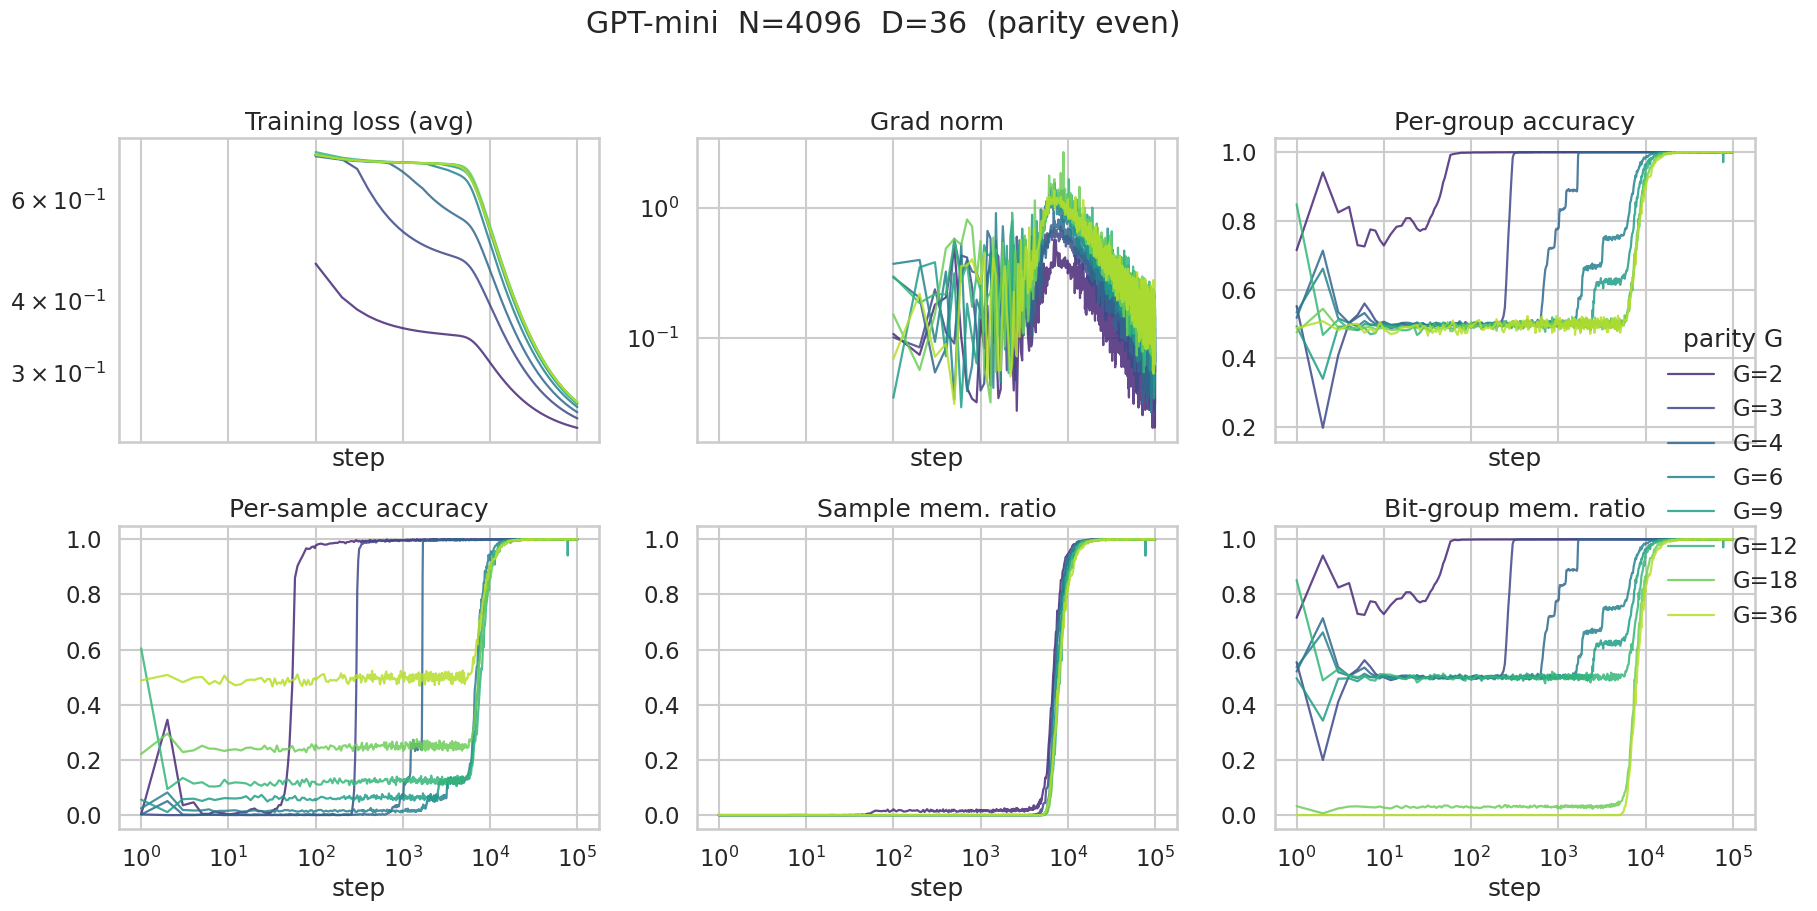

In [4]:
G_VALUES = [2, 3, 4, 6, 9, 12, 18, 36]
g_palette = dict(zip(G_VALUES, sns.color_palette("viridis", n_colors=len(G_VALUES))))

panel_tags = [
    ("Training/Loss_Avg",       "Training loss (avg)",   "log"),
    ("Training/Gradient_Norm",  "Grad norm",             "log"),
    ("Eval/PerGroup_Accuracy",  "Per-group accuracy",    "linear"),
    ("Eval/Sample_Accuracy",    "Per-sample accuracy",   "linear"),
    ("Eval/Sample_Mem_Ratio",   "Sample mem. ratio",     "linear"),
    ("Eval/BitGroup_Mem_Ratio", "Bit-group mem. ratio",  "linear"),
]

def plot_trajectories(size, N, save=True):
    fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
    sub = long_df[(long_df["size"] == size) & (long_df["N"] == N)]
    for ax, (tag, ylabel, yscale) in zip(axes.flat, panel_tags):
        td = sub[sub["tag"] == tag]
        for G, gdf in td.groupby("G"):
            gdf = gdf.sort_values("step")
            ax.plot(gdf["step"], gdf["value"], color=g_palette[G],
                    label=f"G={G}", alpha=0.85, lw=1.6)
        ax.set_title(ylabel)
        ax.set_xscale("log")
        if yscale == "log": ax.set_yscale("log")
        ax.set_xlabel("step")
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right",
               bbox_to_anchor=(1.02, 0.5), title="parity G", frameon=False)
    fig.suptitle(f"GPT-{size}  N={N}  D=36  (parity even)", y=1.02)
    fig.tight_layout()
    if save:
        out = join(FIG_DIR, f"GPT_{size}_N{N}_trajectory_panel.png")
        fig.savefig(out, dpi=130, bbox_inches="tight")
        print("saved:", out)
    plt.show()

plot_trajectories("mini", 4096)

## Same panel for the rest of the (size, N) cells

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_B_N32768_trajectory_panel.png


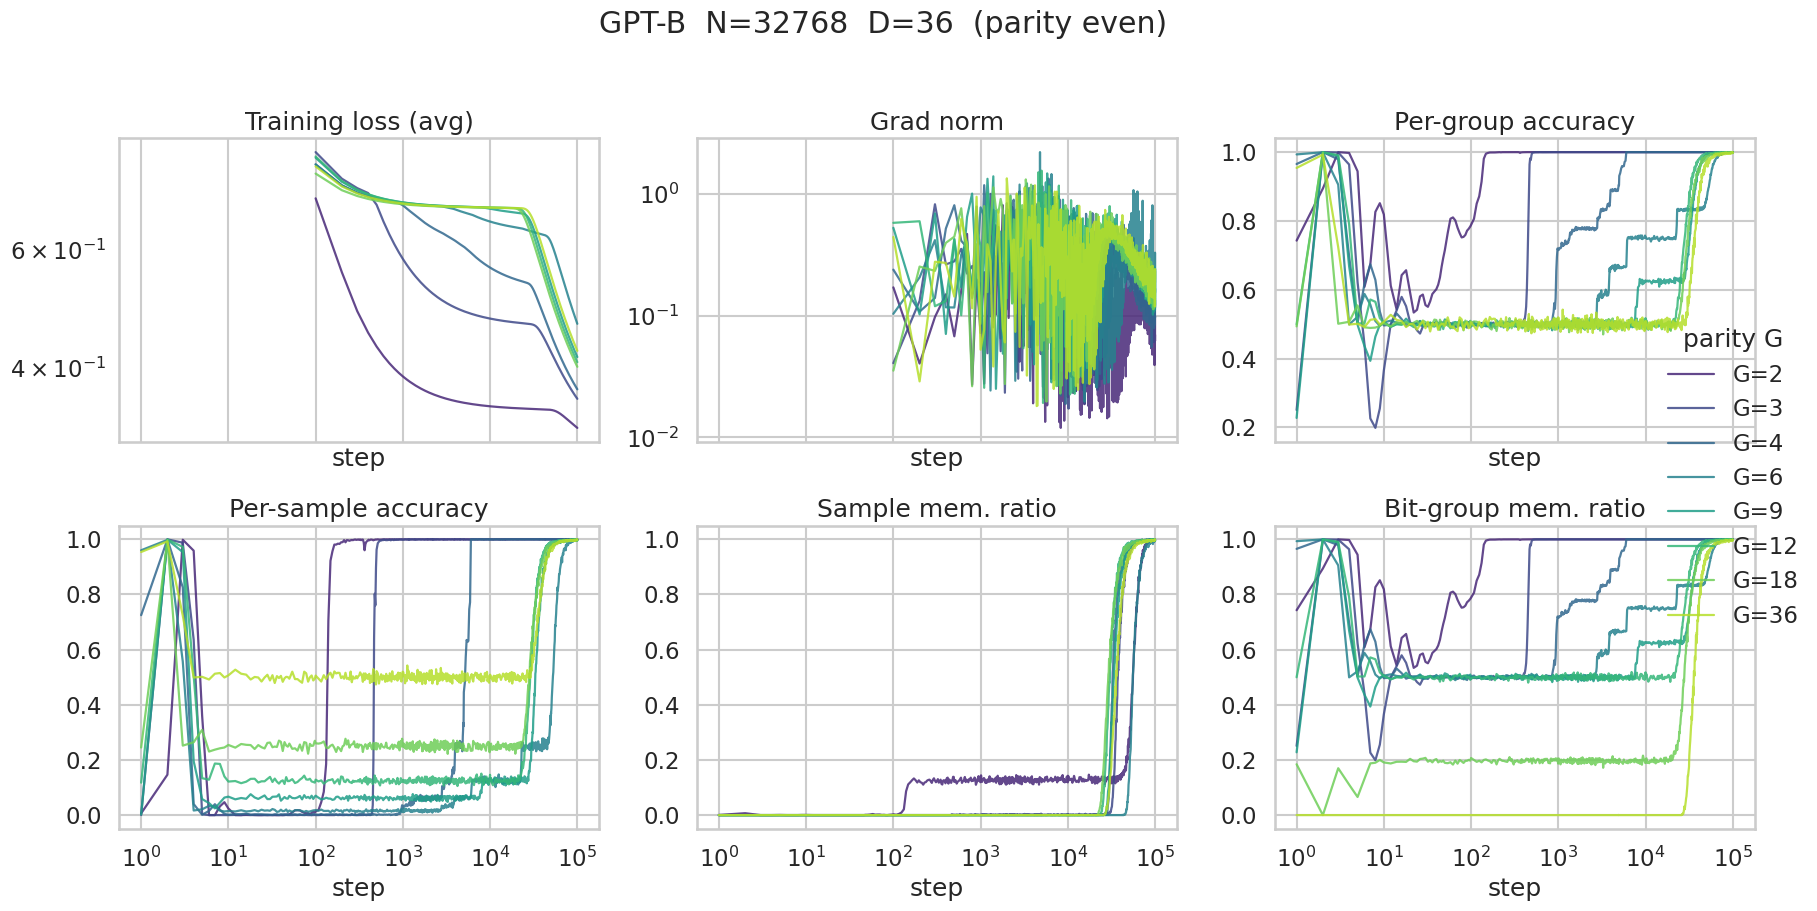

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_mini_N8192_trajectory_panel.png


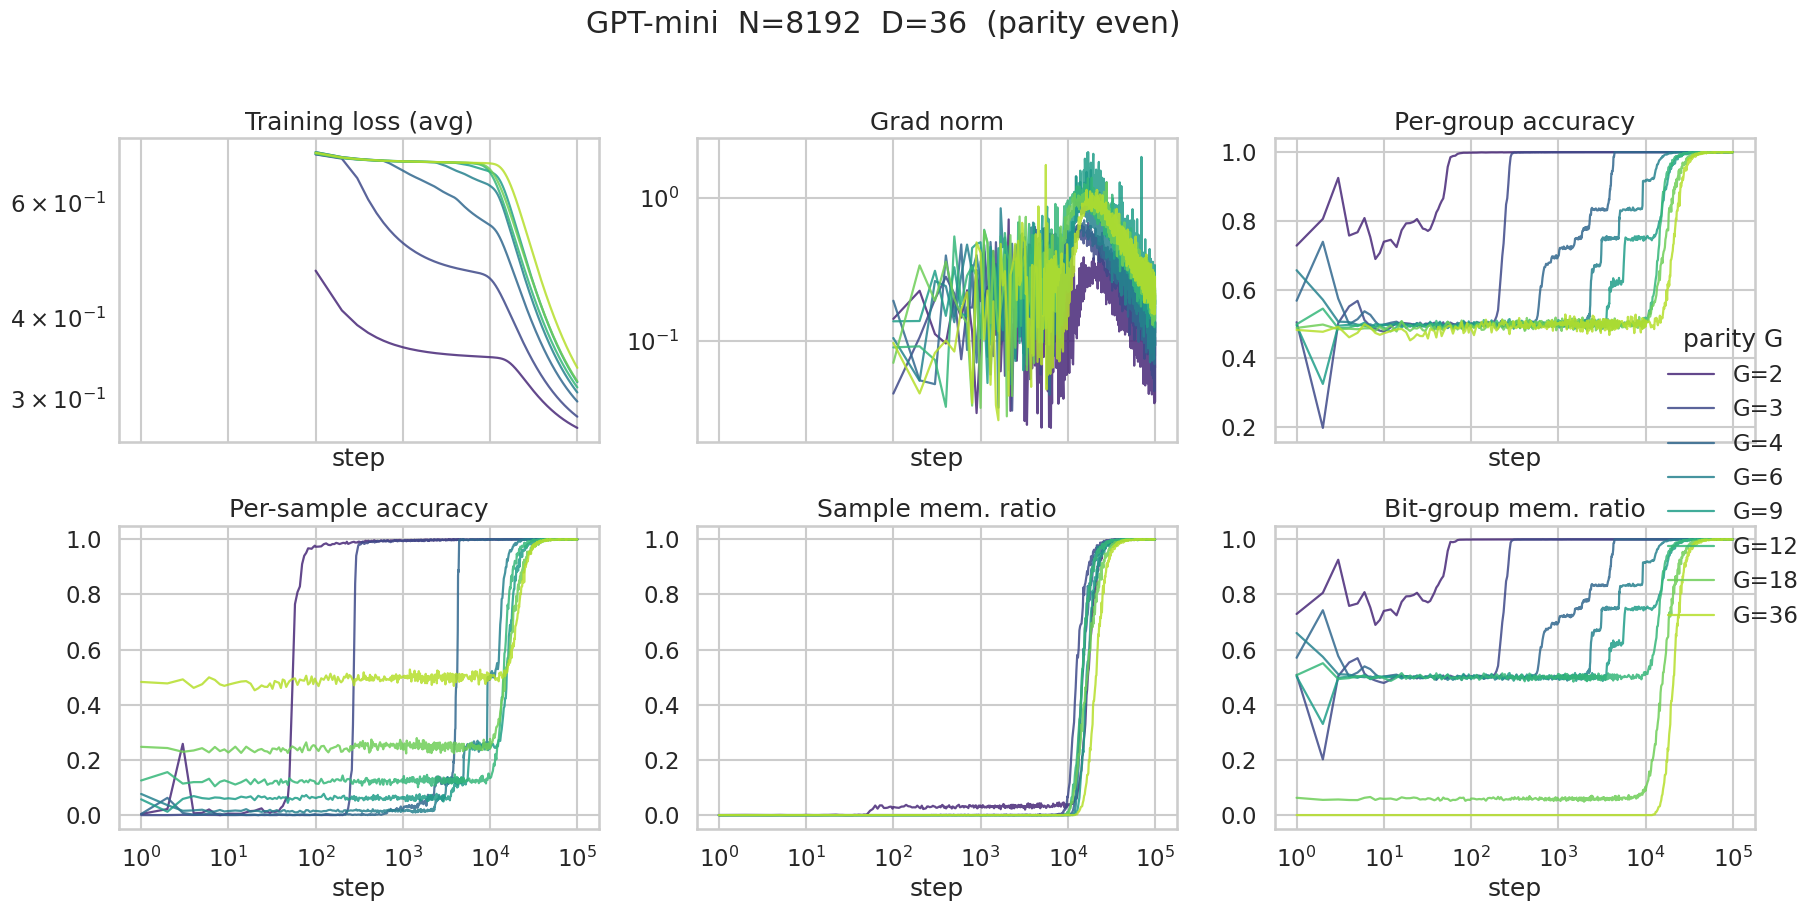

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_mini_N16384_trajectory_panel.png


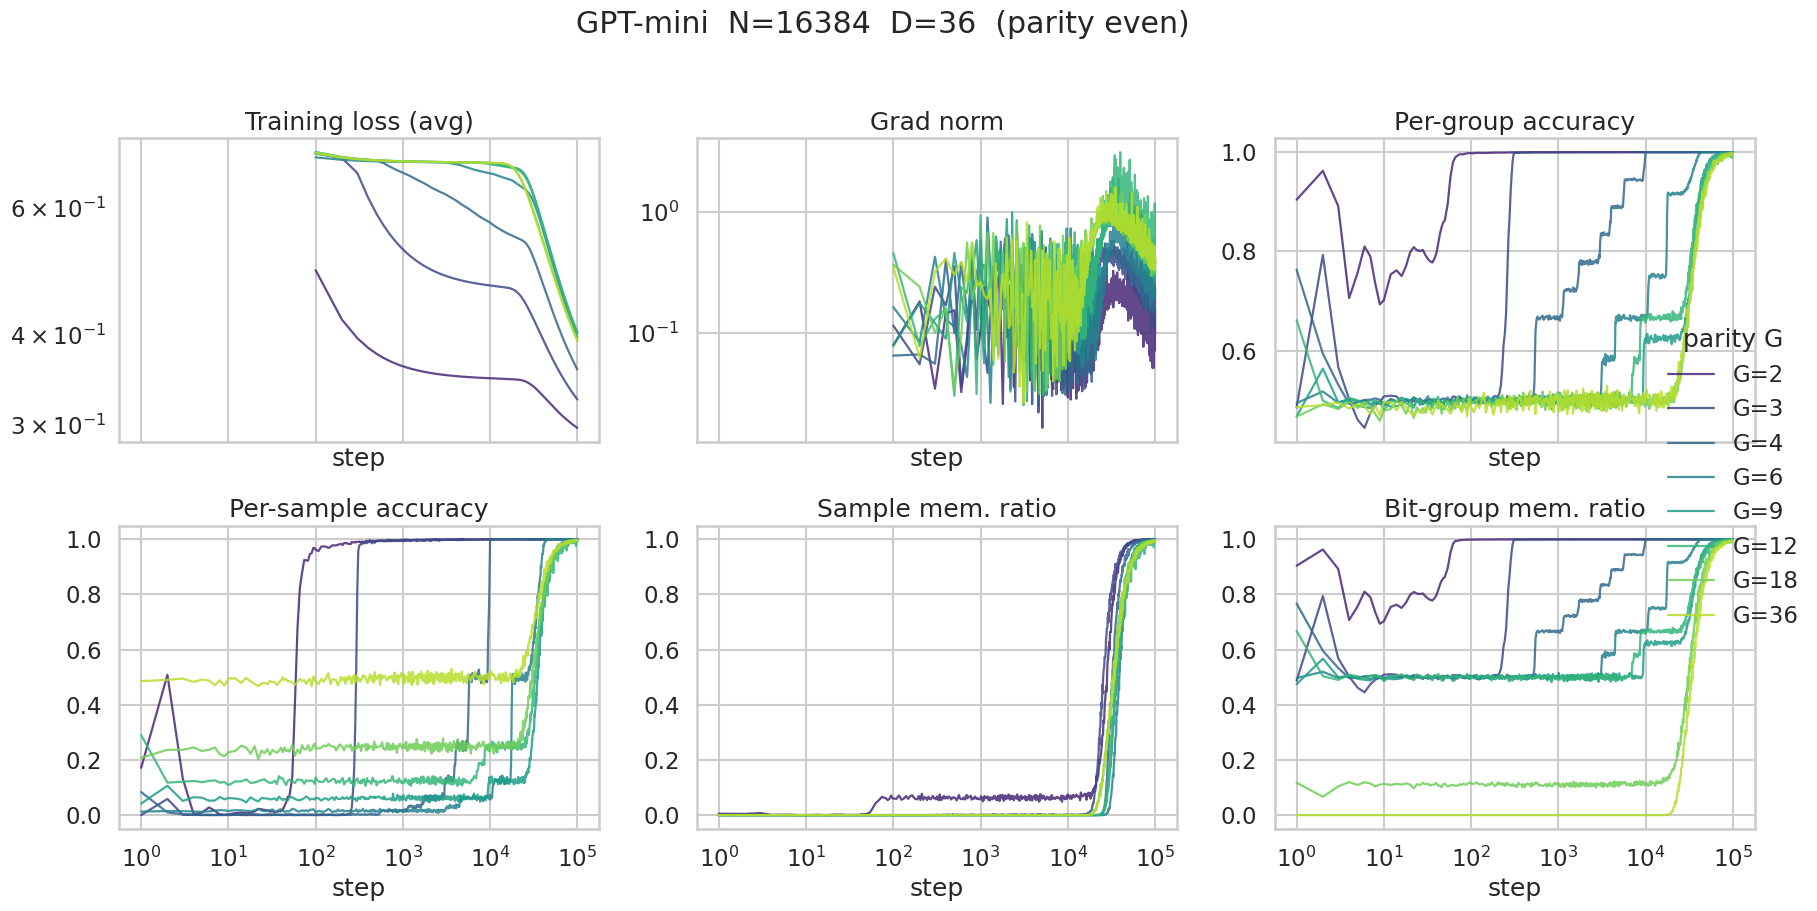

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_mini_N32768_trajectory_panel.png


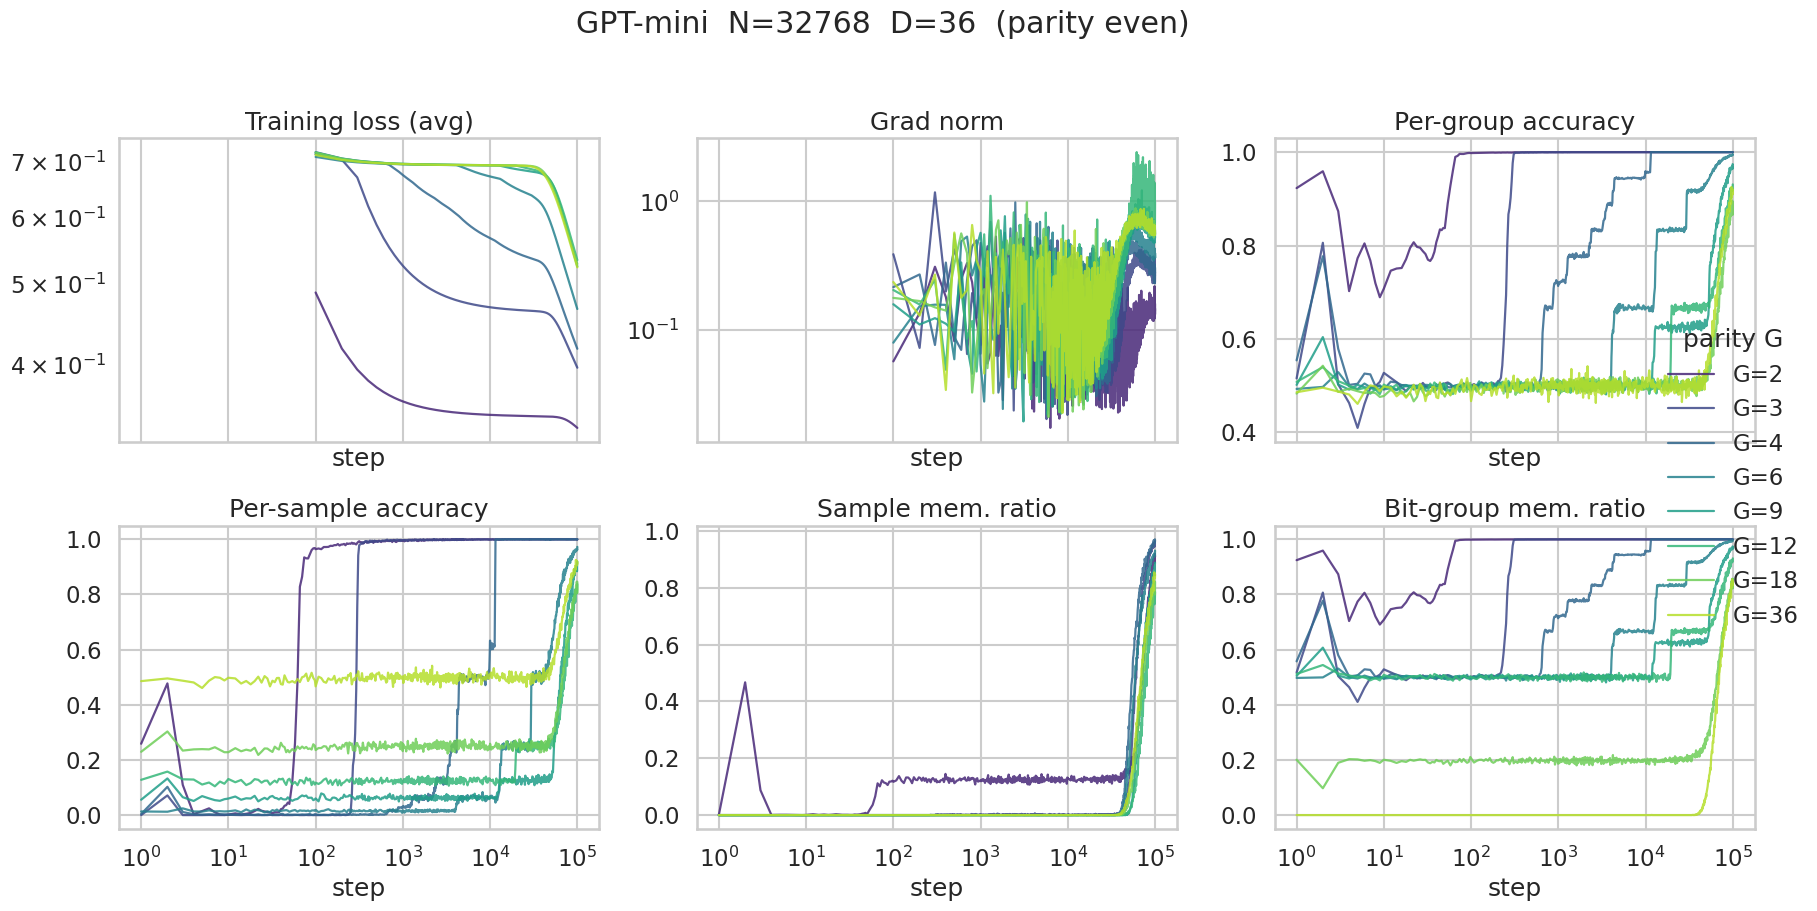

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_nano_N4096_trajectory_panel.png


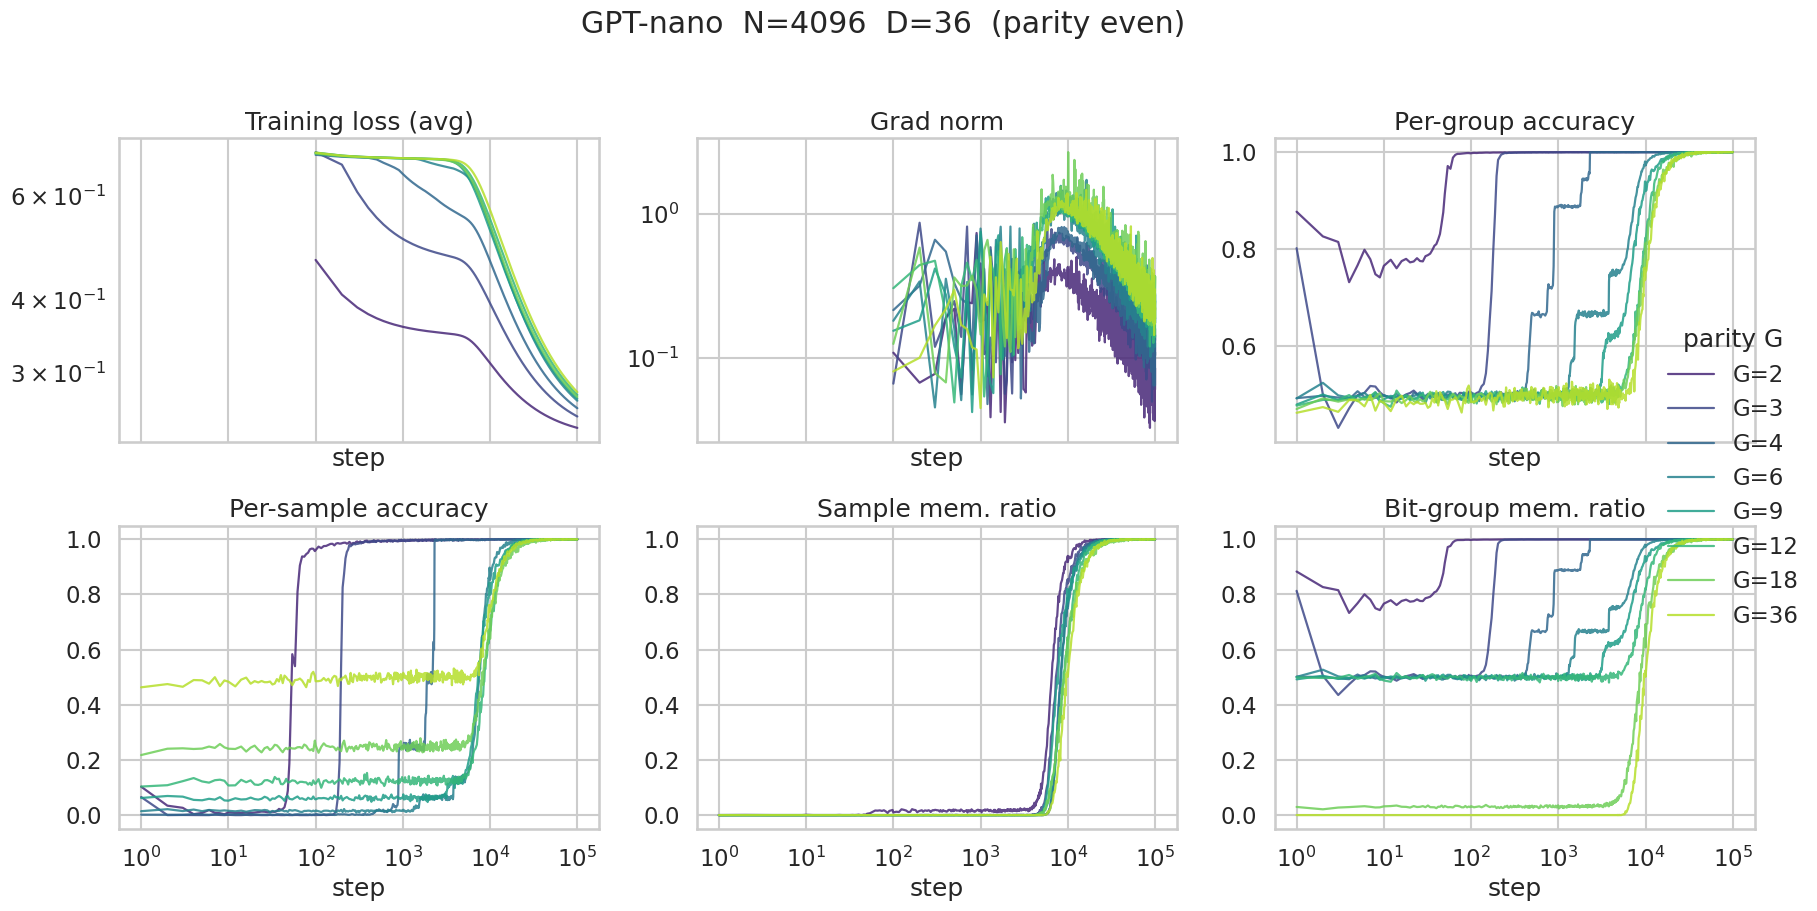

In [5]:
cells = (runs_df.groupby(["size","N"]).size().reset_index().drop(columns=0)
                  .sort_values(["size","N"]))
for _, row in cells.iterrows():
    if (row["size"], row["N"]) == ("mini", 4096):
        continue  # already shown above
    plot_trajectories(row["size"], row["N"])

## How does the same G look across model sizes / N?

Each panel shows GPT runs for one G. Curves vary in `(size, N)` so we can read
- whether bigger N rescues higher-G parity (it should, classically),
- whether nano vs mini vs B differ in convergence speed or asymptote.

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_per-sample-acc_perG.png


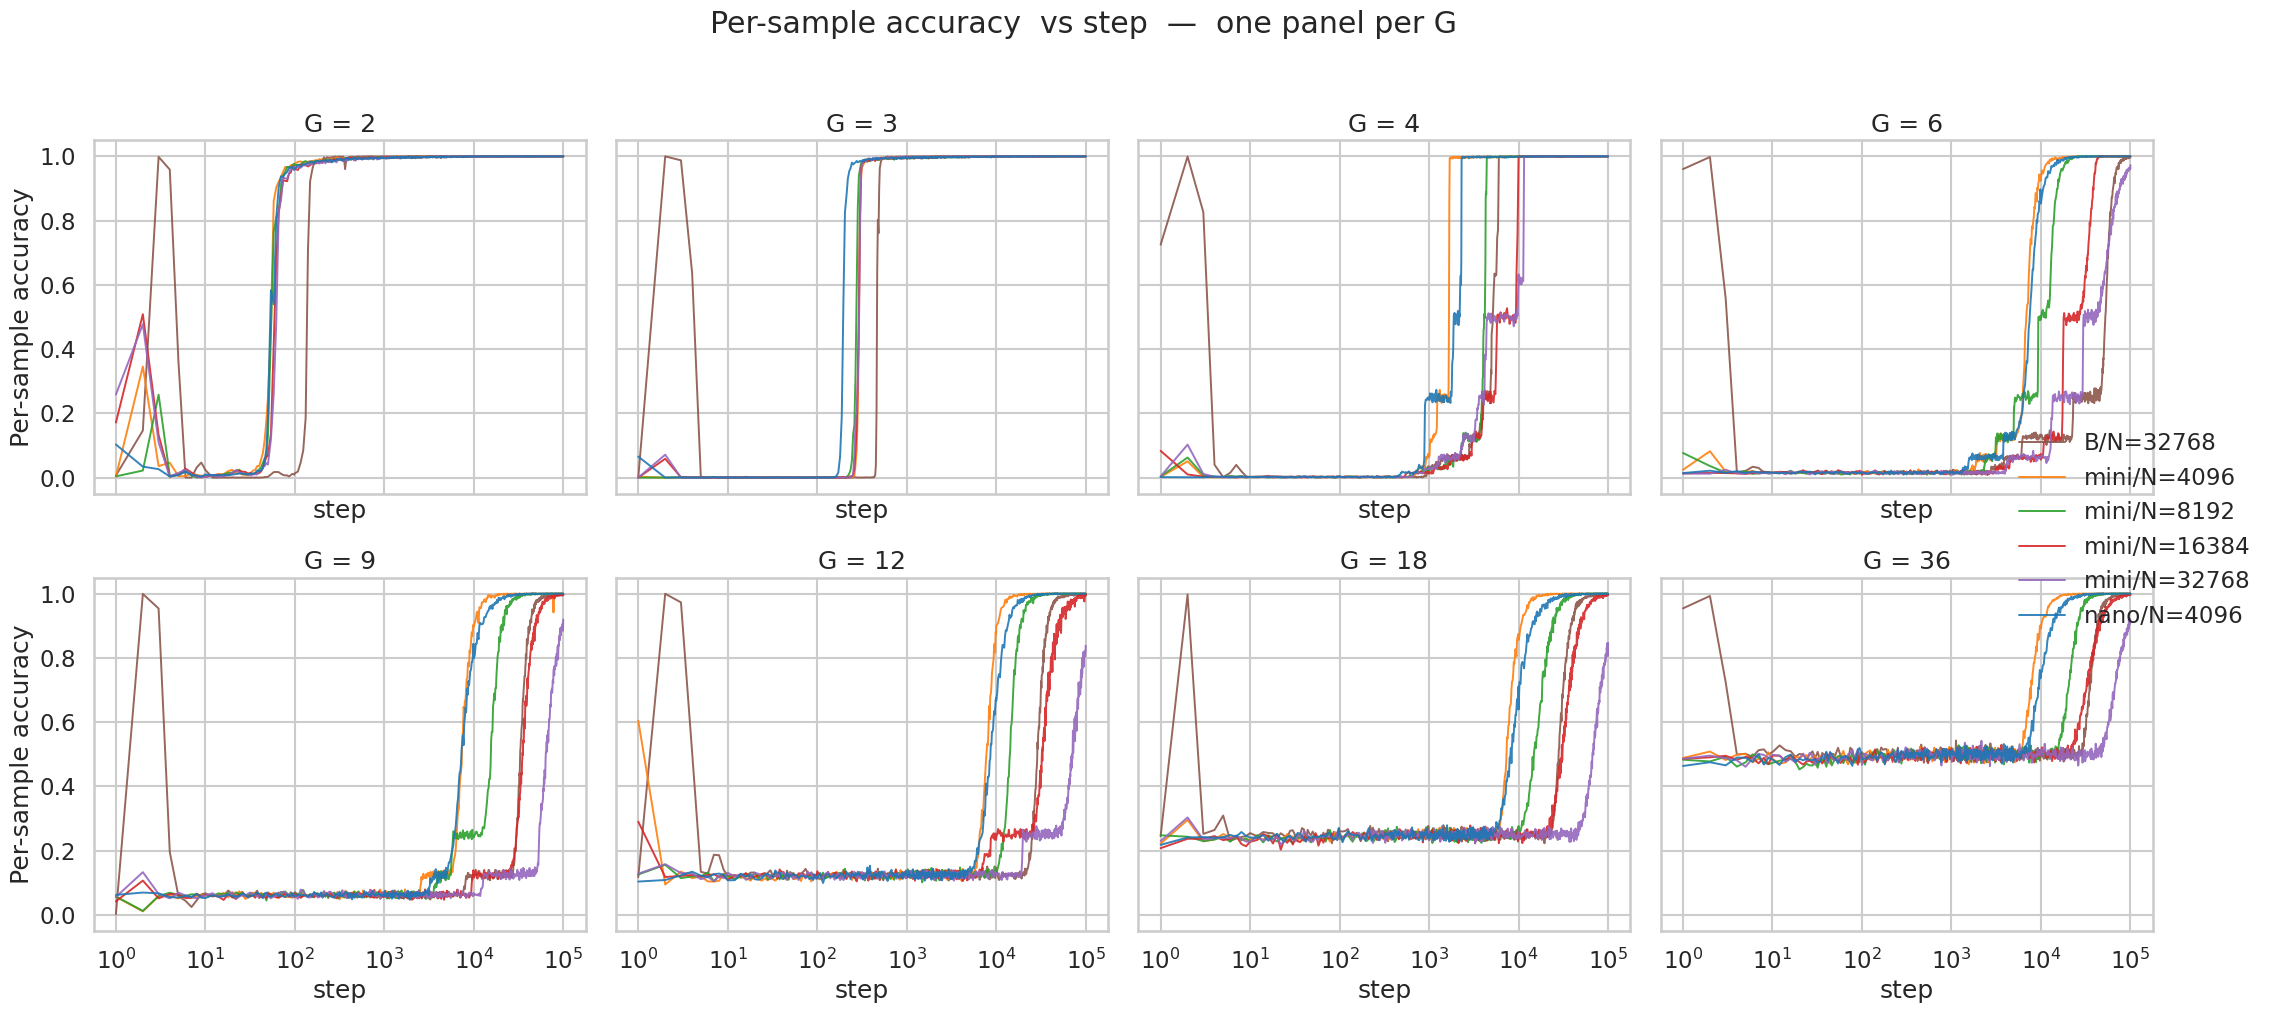

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_per-group-acc_perG.png


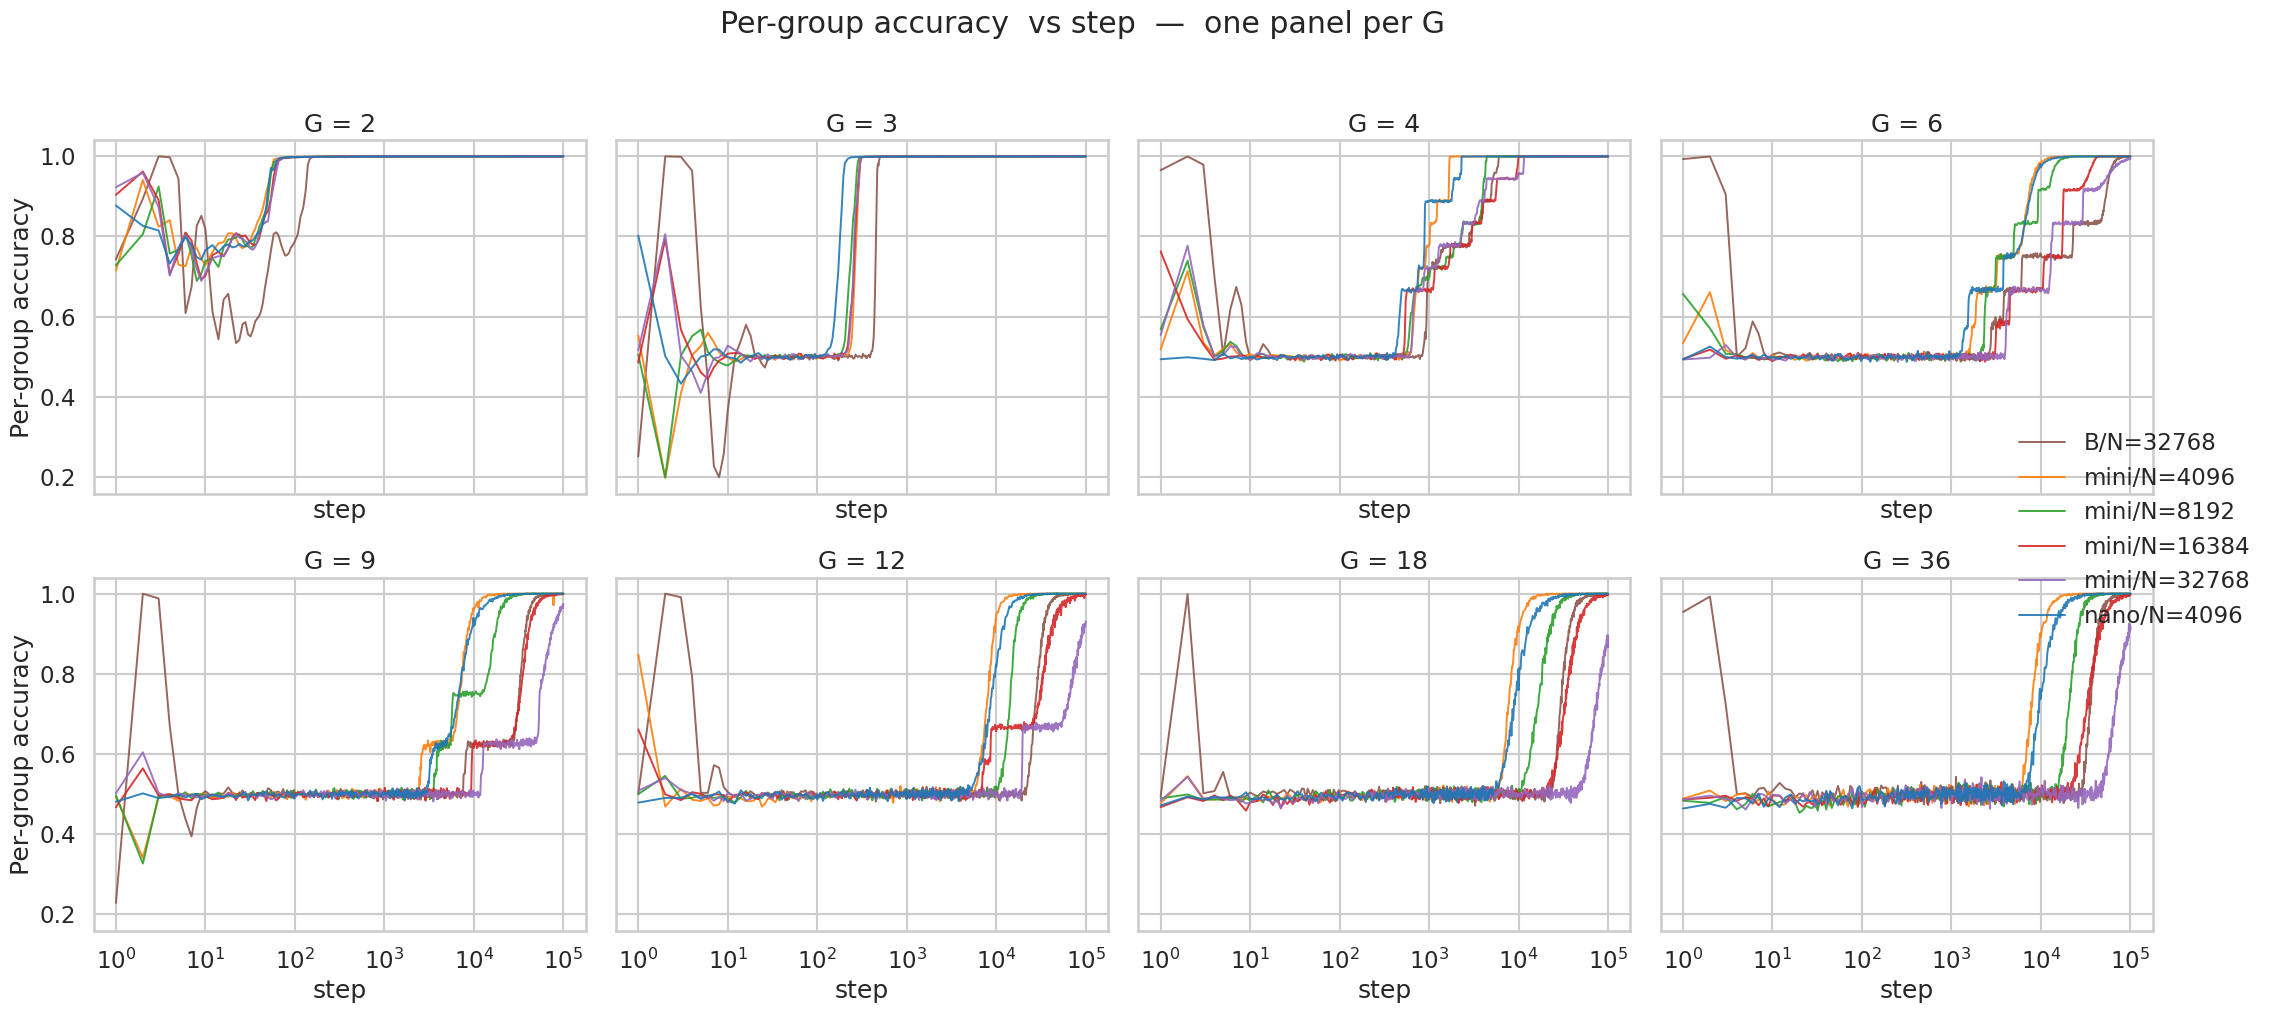

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_sample-mem-ratio_perG.png


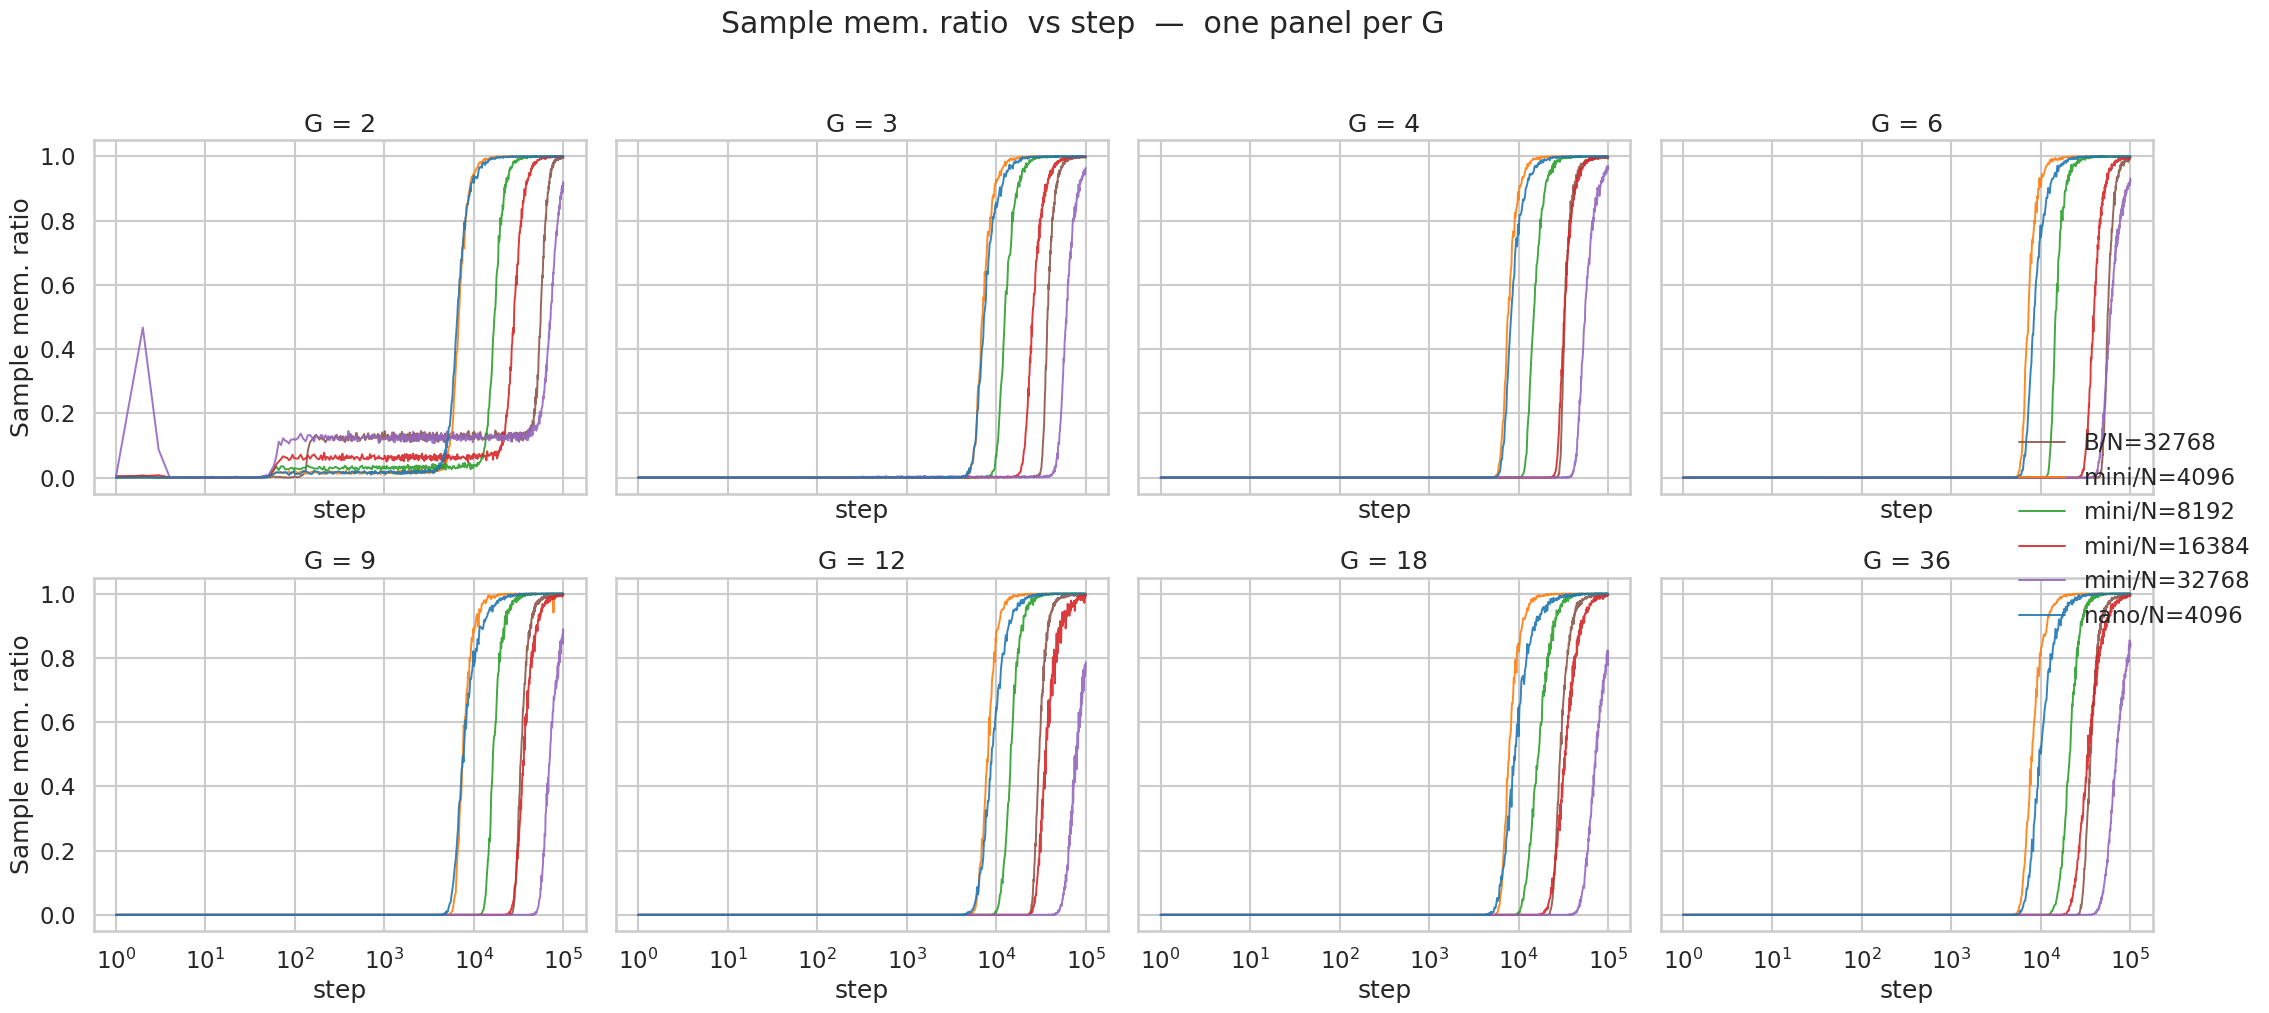

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_loss_perG.png


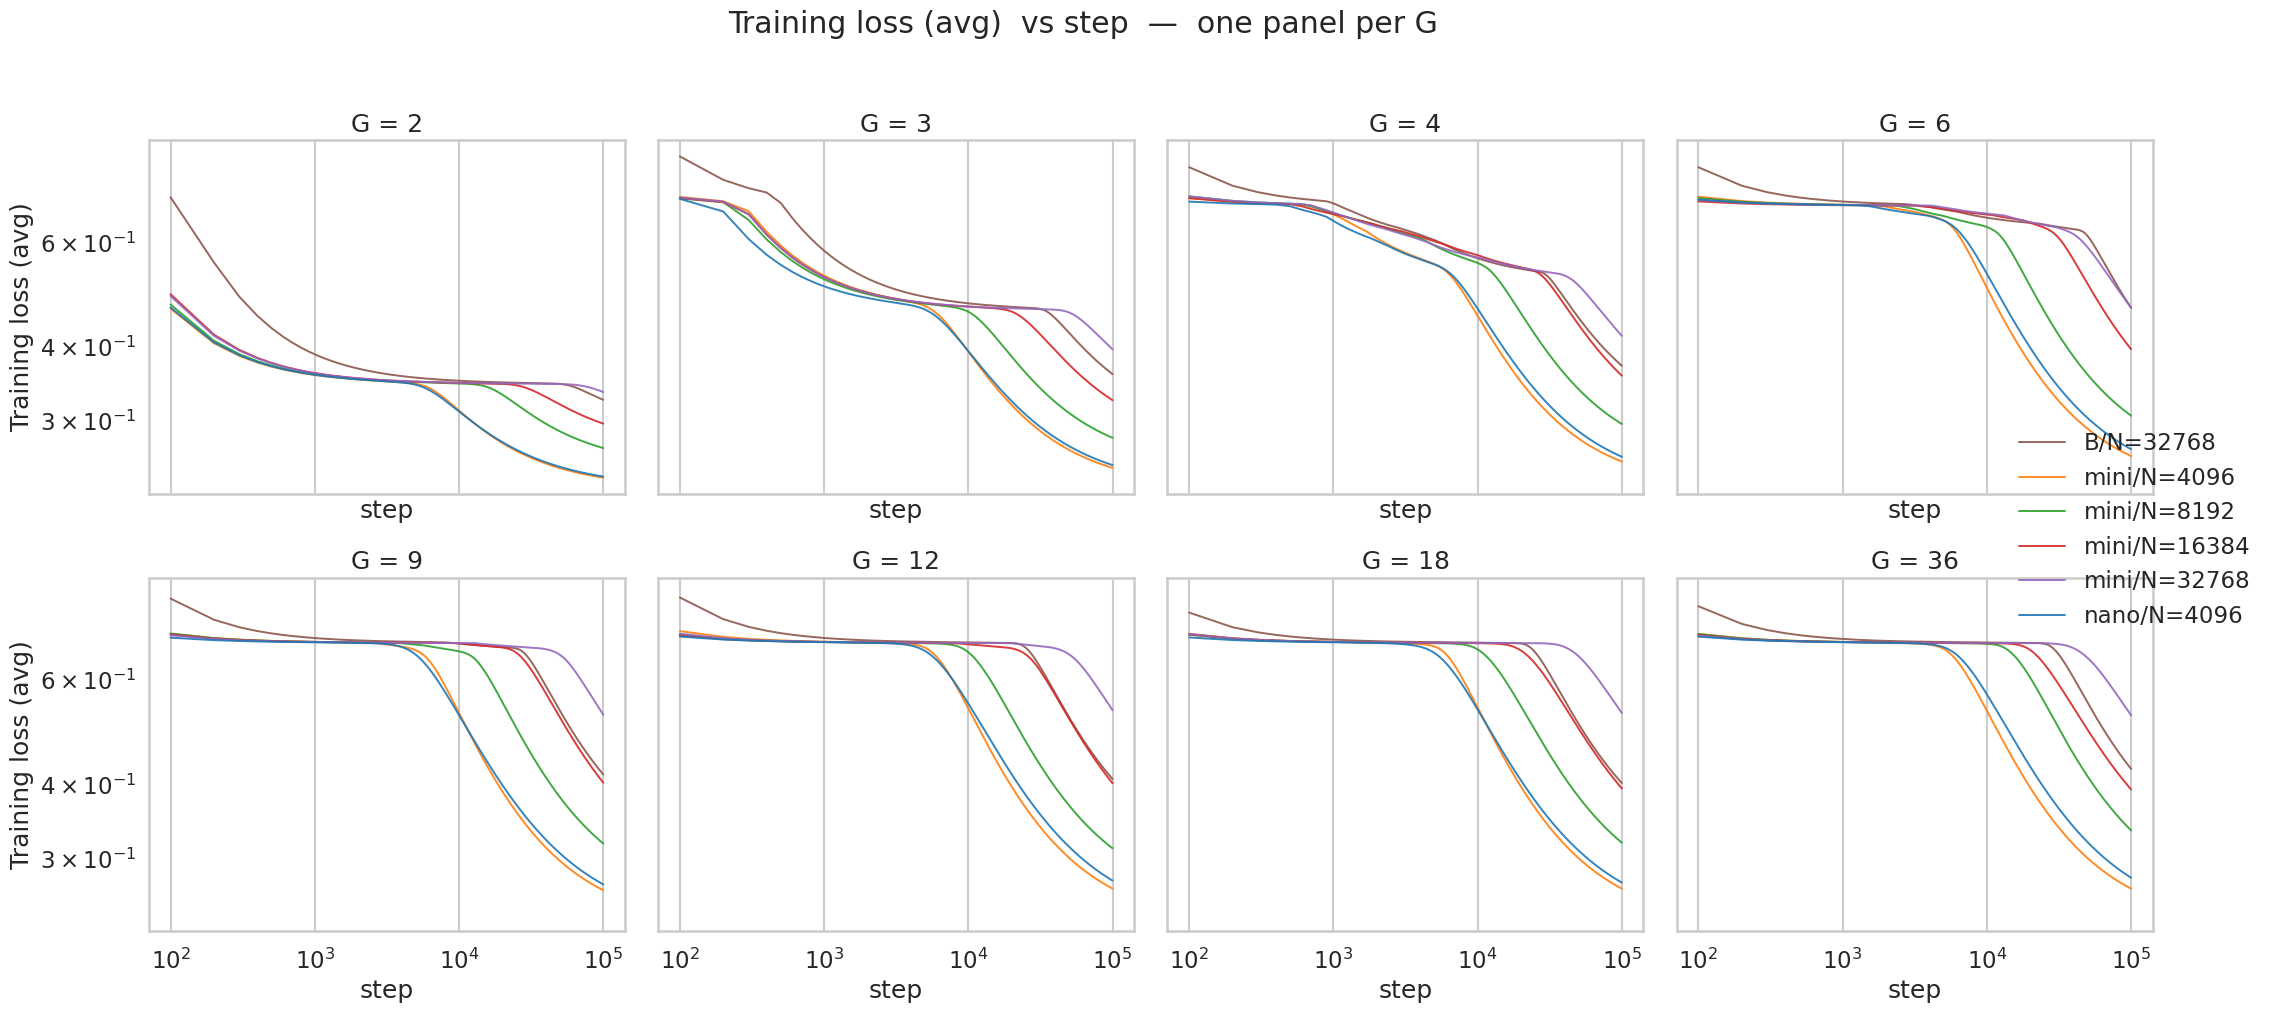

In [6]:
def plot_metric_per_G(tag, ylabel, yscale="linear", save_name=None):
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True, sharex=True)
    runs_meta = runs_df.copy()
    runs_meta["key"] = list(zip(runs_meta["size"], runs_meta["N"]))
    keys = sorted(runs_meta["key"].unique(), key=lambda k: ({"nano":0,"mini":1,"B":2}[k[0]], k[1]))
    style_palette = sns.color_palette("tab10", n_colors=len(keys))
    style_map = dict(zip(keys, style_palette))

    for ax, G in zip(axes.flat, G_VALUES):
        sub = long_df[(long_df["tag"] == tag) & (long_df["G"] == G)]
        for (size, N), gdf in sub.groupby(["size","N"]):
            gdf = gdf.sort_values("step")
            ax.plot(gdf["step"], gdf["value"], color=style_map[(size, N)],
                    lw=1.4, alpha=0.9, label=f"{size}/N={N}")
        ax.set_title(f"G = {G}")
        ax.set_xscale("log")
        if yscale == "log": ax.set_yscale("log")
        ax.set_xlabel("step")
    axes[0,0].set_ylabel(ylabel); axes[1,0].set_ylabel(ylabel)
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center right",
               bbox_to_anchor=(1.04, 0.5), frameon=False)
    fig.suptitle(f"{ylabel}  vs step  —  one panel per G", y=1.02)
    fig.tight_layout()
    if save_name:
        out = join(FIG_DIR, save_name)
        fig.savefig(out, dpi=130, bbox_inches="tight")
        print("saved:", out)
    plt.show()

plot_metric_per_G("Eval/Sample_Accuracy", "Per-sample accuracy",
                  save_name="GPT_per-sample-acc_perG.png")
plot_metric_per_G("Eval/PerGroup_Accuracy", "Per-group accuracy",
                  save_name="GPT_per-group-acc_perG.png")
plot_metric_per_G("Eval/Sample_Mem_Ratio", "Sample mem. ratio",
                  save_name="GPT_sample-mem-ratio_perG.png")
plot_metric_per_G("Training/Loss_Avg", "Training loss (avg)", yscale="log",
                  save_name="GPT_loss_perG.png")

## Final-step summary table & heatmaps

Take the last logged value per `(size, N, G)` for each metric, build a comparable summary, and visualize as heatmaps.

In [7]:
final_df = (long_df.sort_values("step")
                   .groupby(["exp_name","size","N","G","tag"], as_index=False)
                   .last())
final_pivot = final_df.pivot_table(
    index=["size","N","G"], columns="tag", values="value", aggfunc="last"
).reset_index()

# Save as CSV for downstream notebooks / docs
out_csv = "/n/home12/binxuwang/Github/DiffusionAttnConsistency/tables/GPT_parity_final_metrics.csv"
final_pivot.to_csv(out_csv, index=False)
print("wrote", out_csv)
final_pivot

wrote /n/home12/binxuwang/Github/DiffusionAttnConsistency/tables/GPT_parity_final_metrics.csv


tag,size,N,G,Eval/BitGroup_Mem_Num,Eval/BitGroup_Mem_Ratio,Eval/PerGroup_Accuracy,Eval/PerGroup_Correct,Eval/Sample_Accuracy,Eval/Sample_Correct,Eval/Sample_Mem_Num,Eval/Sample_Mem_Ratio,Training/Gradient_Norm,Training/Learning_Rate,Training/Loss_Avg,Training/Loss_Step
0,B,32768,2,36864.0,1.000000,1.000000,36864.0,1.000000,2048.0,2040.0,0.996094,0.069600,0.0001,0.325936,0.292653
1,B,32768,3,24576.0,1.000000,1.000000,24576.0,1.000000,2048.0,2040.0,0.996094,0.115522,0.0001,0.360127,0.293292
2,B,32768,4,18432.0,1.000000,1.000000,18432.0,1.000000,2048.0,2034.0,0.993164,0.096123,0.0001,0.372055,0.292394
3,B,32768,6,12284.0,0.999674,0.999674,12284.0,0.998047,2044.0,2039.0,0.995605,0.154916,0.0001,0.465915,0.293412
4,B,32768,9,8187.0,0.999390,0.999390,8187.0,0.998047,2044.0,2044.0,0.998047,0.118475,0.0001,0.415639,0.292328
5,B,32768,12,6142.0,0.999674,0.999674,6142.0,0.999023,2046.0,2045.0,0.998535,0.167312,0.0001,0.408349,0.293180
6,B,32768,18,4083.0,0.996826,0.997314,4085.0,0.996094,2040.0,2039.0,0.995605,0.187703,0.0001,0.402011,0.295315
7,B,32768,36,2046.0,0.999023,0.999023,2046.0,0.999023,2046.0,2046.0,0.999023,0.198569,0.0001,0.424639,0.293619
8,mini,4096,2,36864.0,1.000000,1.000000,36864.0,1.000000,2048.0,2047.0,0.999512,0.031081,0.0001,0.240827,0.231326
9,mini,4096,3,24576.0,1.000000,1.000000,24576.0,1.000000,2048.0,2048.0,1.000000,0.066066,0.0001,0.250152,0.231837


saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_finalacc_heatmap.png


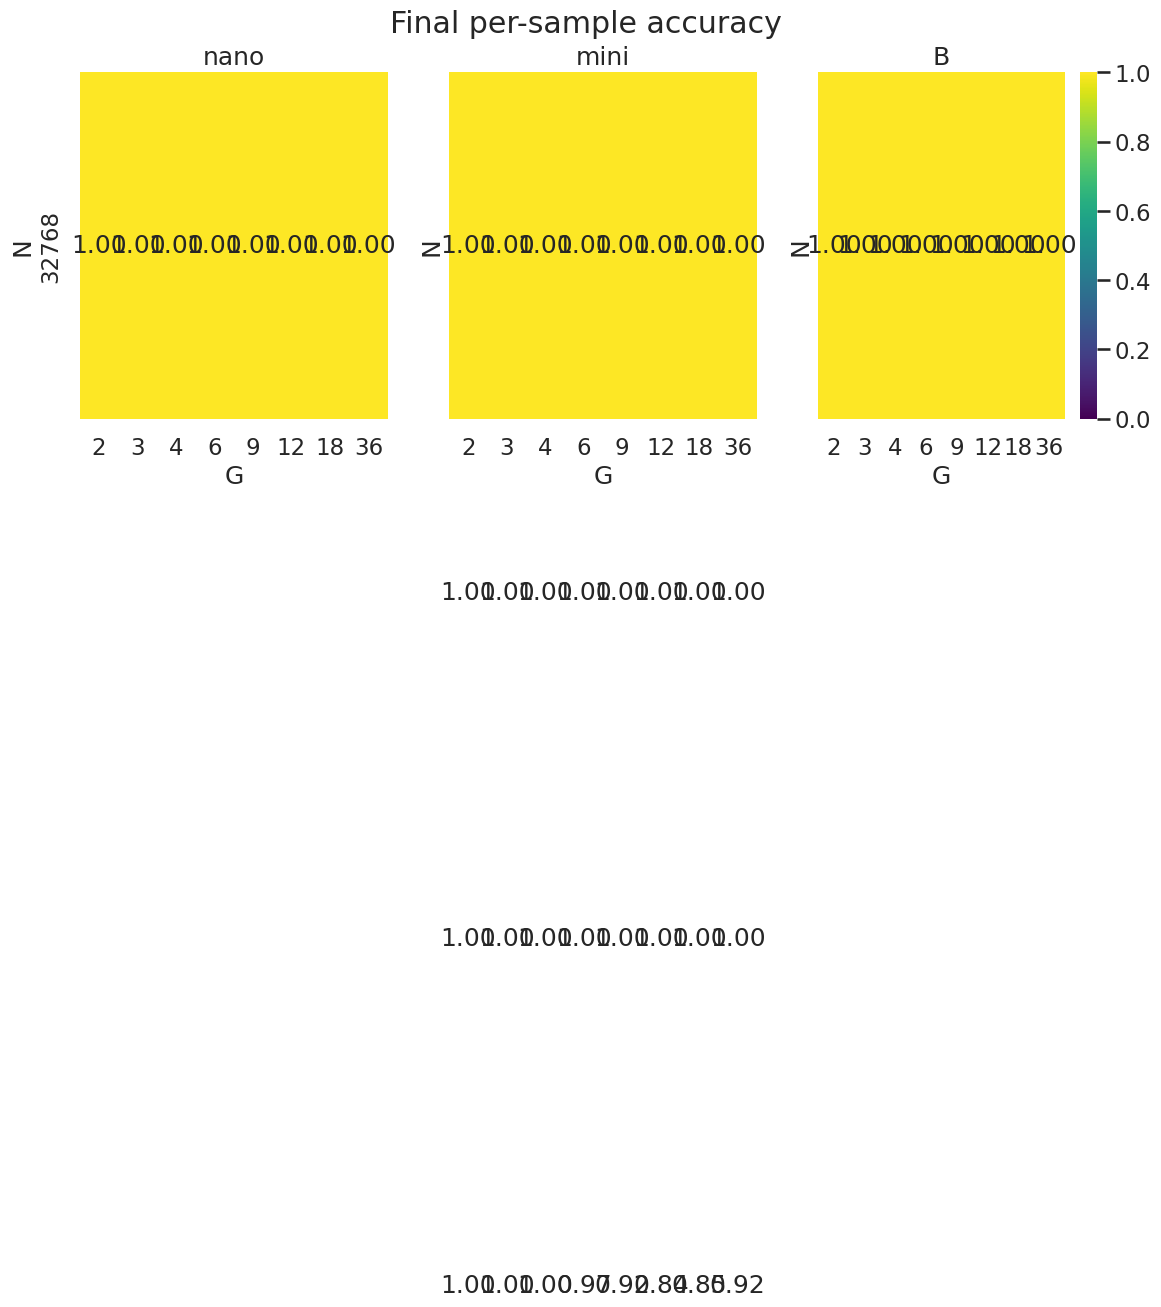

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_finalpergroup_heatmap.png


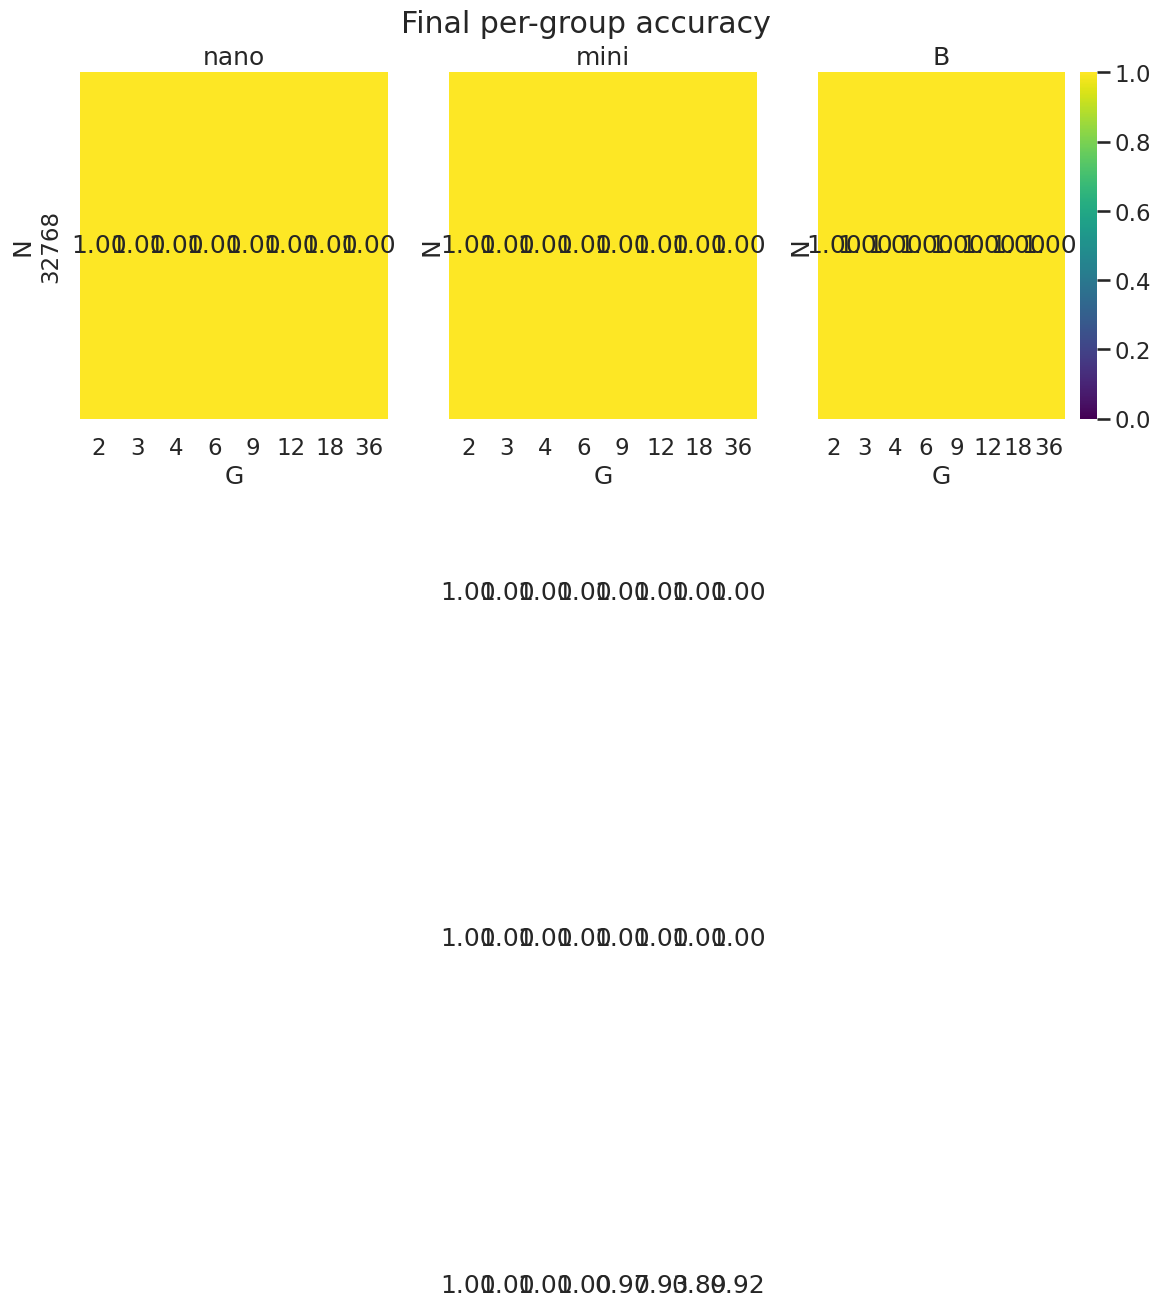

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_finalmem_heatmap.png


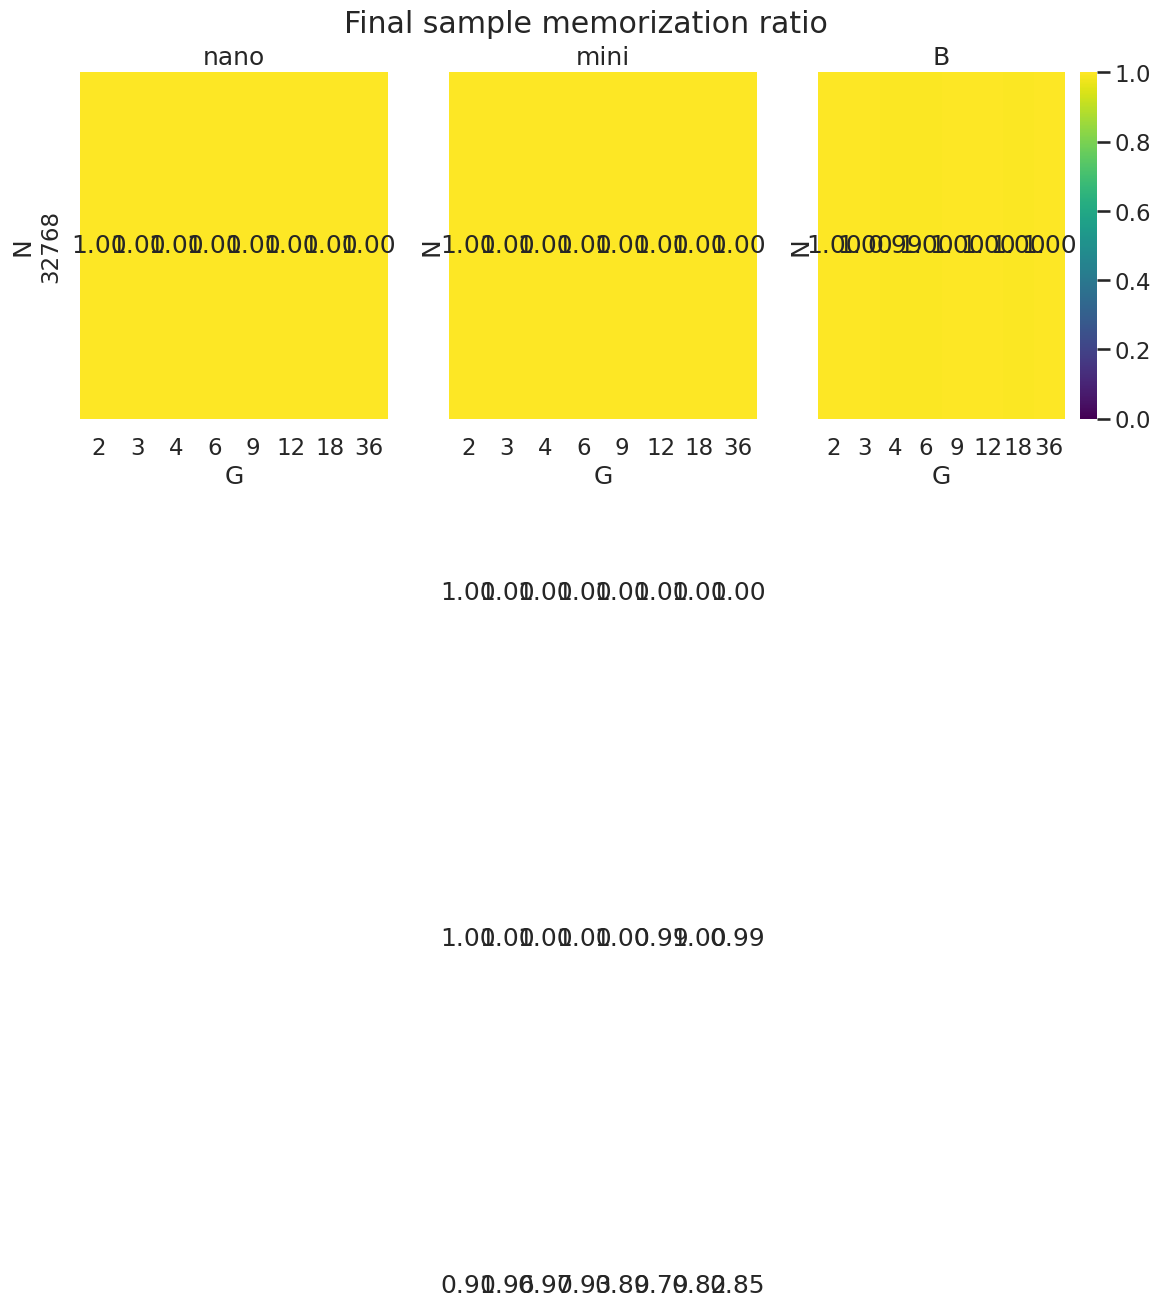

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_finalloss_heatmap.png


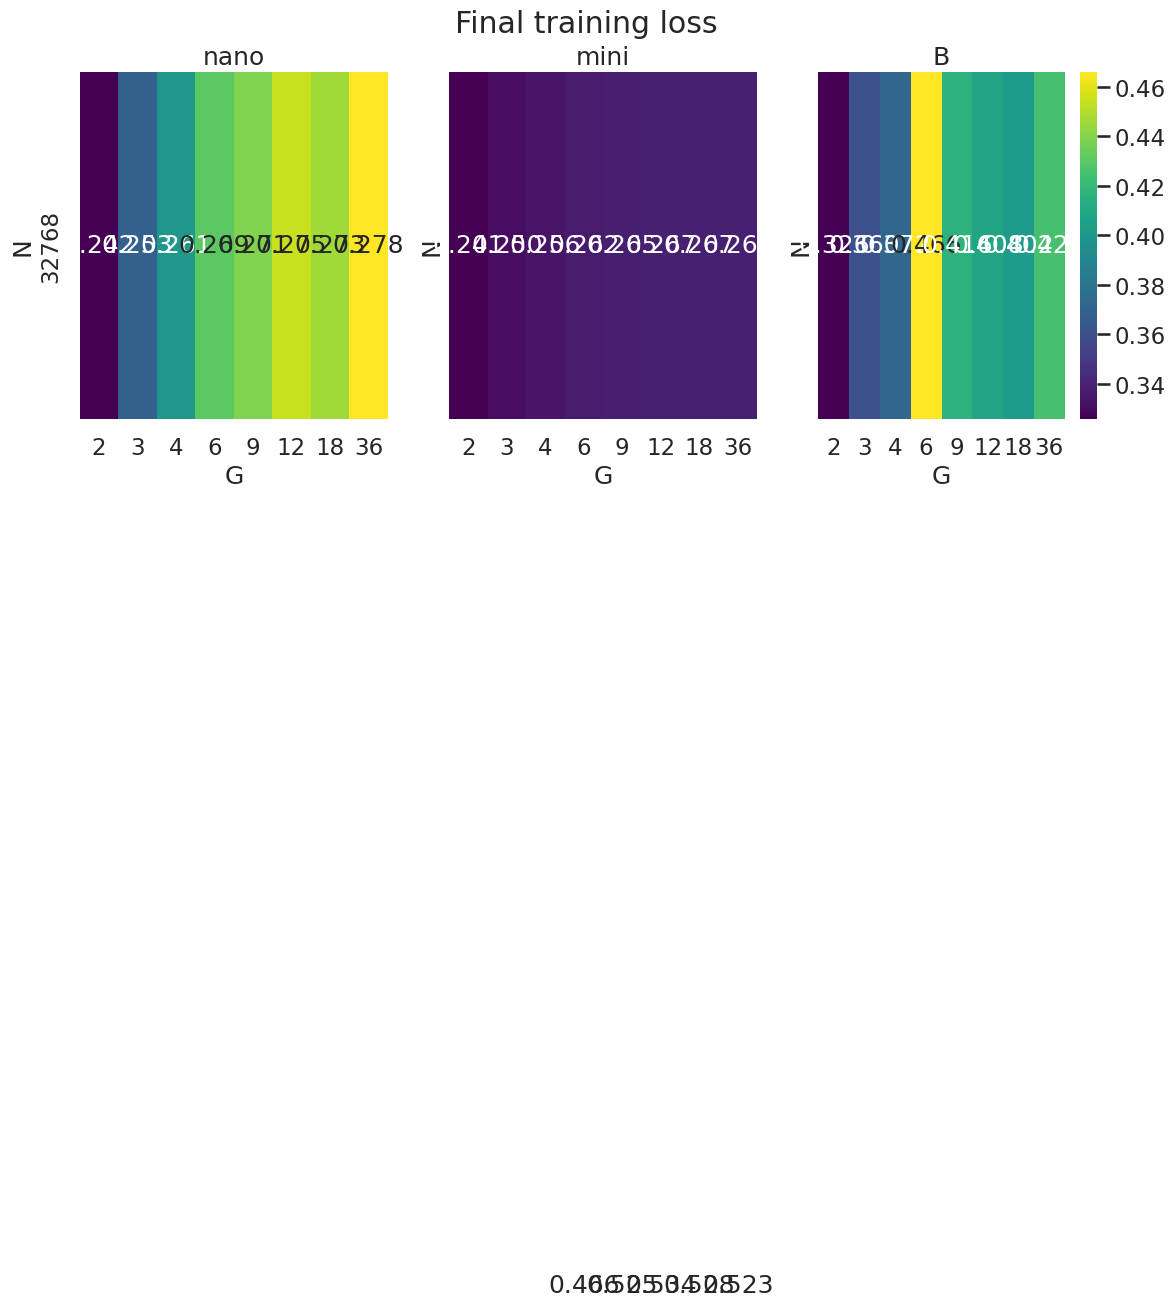

In [8]:
def heatmap_for(tag, title, fmt=".2f", vmin=None, vmax=None, save=None):
    sizes = ["nano","mini","B"]
    sizes_present = [s for s in sizes if s in final_pivot["size"].unique()]
    fig, axes = plt.subplots(1, len(sizes_present),
                             figsize=(4.5 * len(sizes_present), 4.5),
                             sharey=True)
    if len(sizes_present) == 1:
        axes = [axes]
    for ax, size in zip(axes, sizes_present):
        sub = final_pivot[final_pivot["size"] == size]
        if tag not in sub.columns or sub[tag].isna().all():
            ax.set_visible(False); continue
        mat = sub.pivot(index="N", columns="G", values=tag)
        sns.heatmap(mat, annot=True, fmt=fmt, cmap="viridis",
                    vmin=vmin, vmax=vmax, ax=ax,
                    cbar=(ax is axes[-1]))
        ax.set_title(f"{size}")
        ax.set_xlabel("G"); ax.set_ylabel("N")
    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if save:
        out = join(FIG_DIR, save)
        fig.savefig(out, dpi=130, bbox_inches="tight")
        print("saved:", out)
    plt.show()

heatmap_for("Eval/Sample_Accuracy",   "Final per-sample accuracy",
            vmin=0, vmax=1, save="GPT_finalacc_heatmap.png")
heatmap_for("Eval/PerGroup_Accuracy", "Final per-group accuracy",
            vmin=0, vmax=1, save="GPT_finalpergroup_heatmap.png")
heatmap_for("Eval/Sample_Mem_Ratio",  "Final sample memorization ratio",
            vmin=0, vmax=1, save="GPT_finalmem_heatmap.png")
heatmap_for("Training/Loss_Avg",      "Final training loss",
            fmt=".3f", save="GPT_finalloss_heatmap.png")

## Time-to-threshold ("solve step")

For each run, the first step at which `Eval/Sample_Accuracy` crosses 0.5 / 0.9 / 0.99.
NaN means the threshold is never reached within `nsteps`.

In [9]:
def first_crossing(df, threshold):
    df = df.sort_values("step")
    above = df[df["value"] >= threshold]
    return int(above["step"].iloc[0]) if len(above) else np.nan

records = []
for (size, N, G), sub in long_df[long_df["tag"]=="Eval/Sample_Accuracy"].groupby(["size","N","G"]):
    rec = {"size": size, "N": N, "G": G}
    for thr in [0.5, 0.9, 0.99]:
        rec[f"step_to_{thr}"] = first_crossing(sub, thr)
    records.append(rec)
solve_df = pd.DataFrame(records).sort_values(["size","N","G"]).reset_index(drop=True)
solve_df

,size,N,G,step_to_0.5,step_to_0.9,step_to_0.99
0,B,32768,2,3,3.0,3.0
1,B,32768,3,2,2.0,2.0
2,B,32768,4,1,2.0,2.0
3,B,32768,6,1,1.0,2.0
4,B,32768,9,2,2.0,2.0
5,B,32768,12,2,2.0,2.0
6,B,32768,18,2,2.0,2.0
7,B,32768,36,1,1.0,2.0
8,mini,4096,2,58,62.0,188.0
9,mini,4096,3,300,308.0,356.0


saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_solve_step_0.5.png


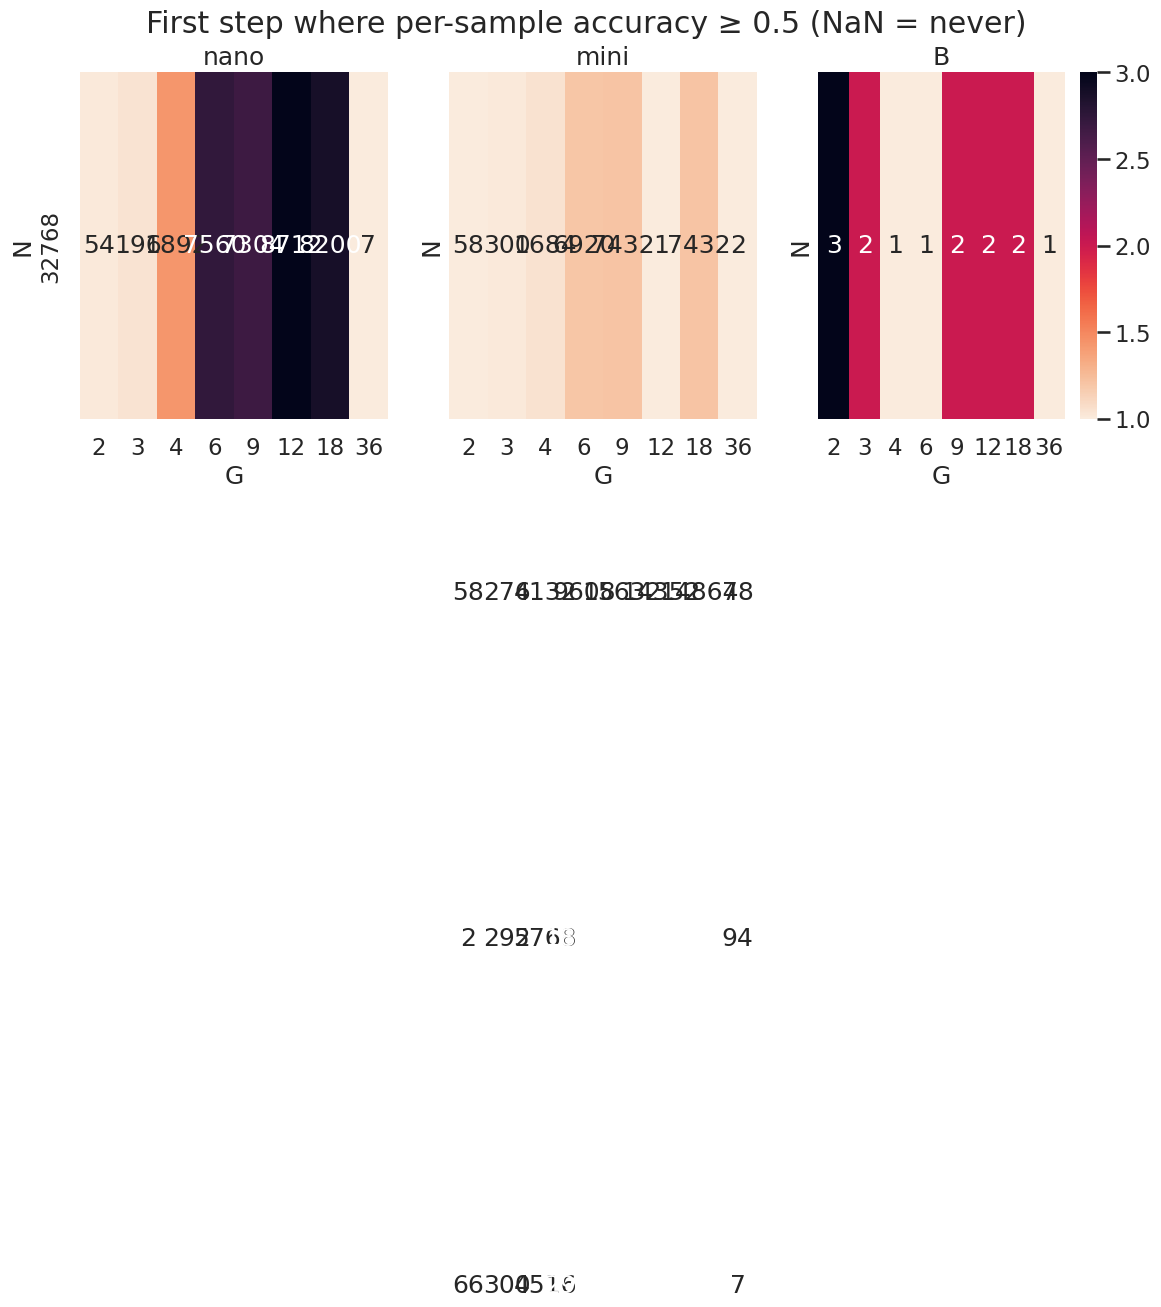

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_solve_step_0.9.png


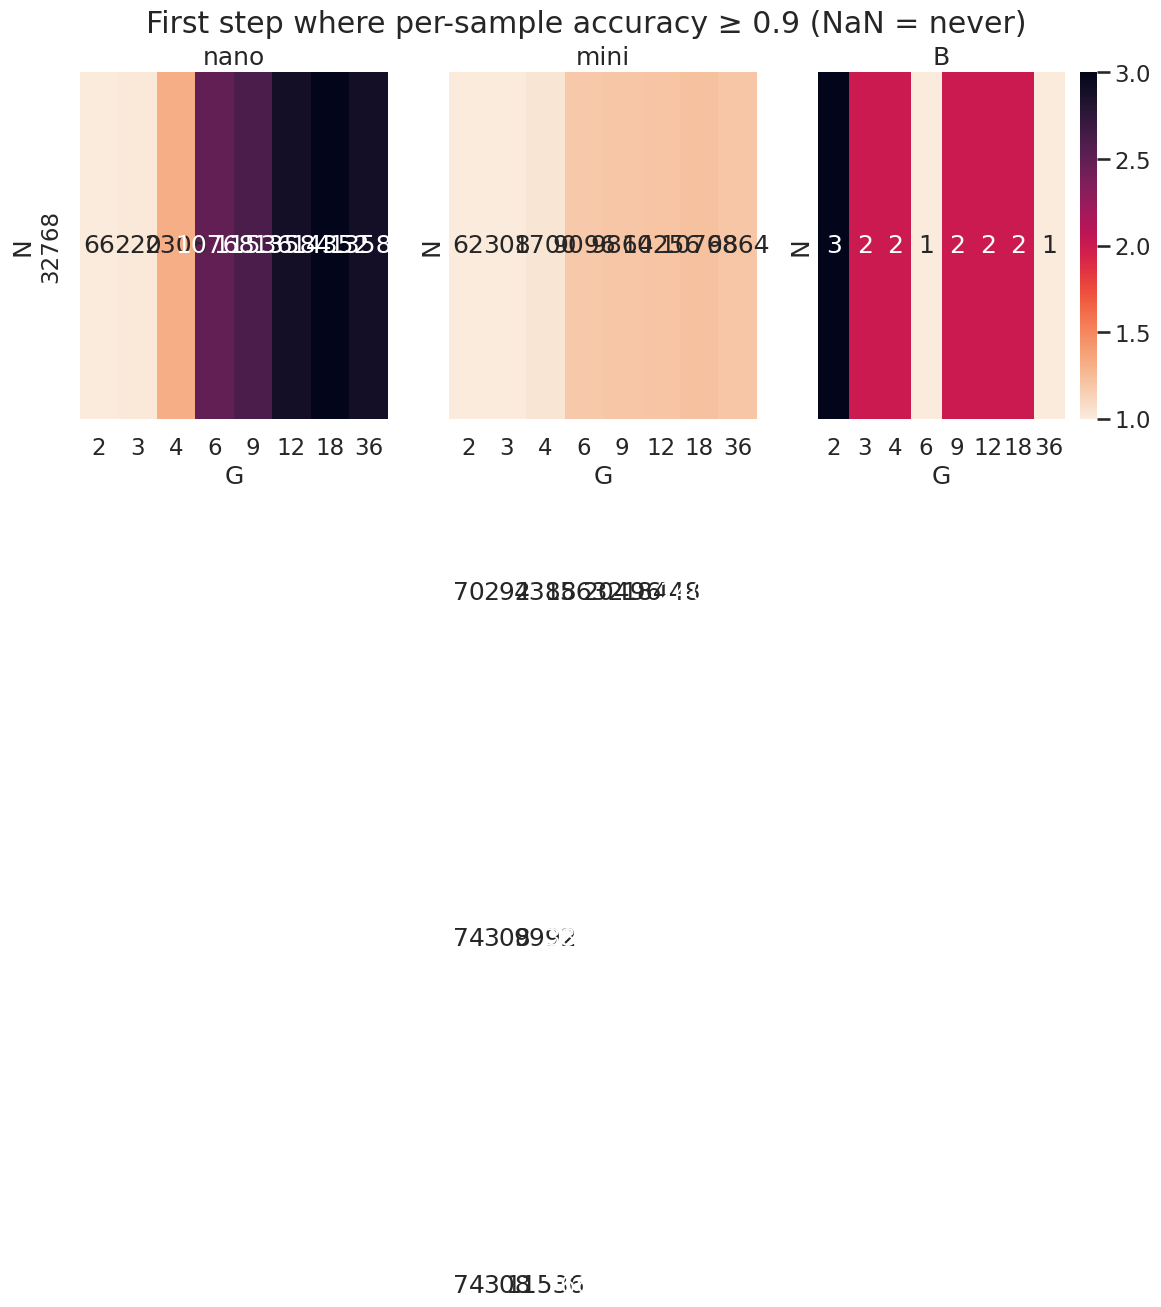

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_solve_step_0.99.png


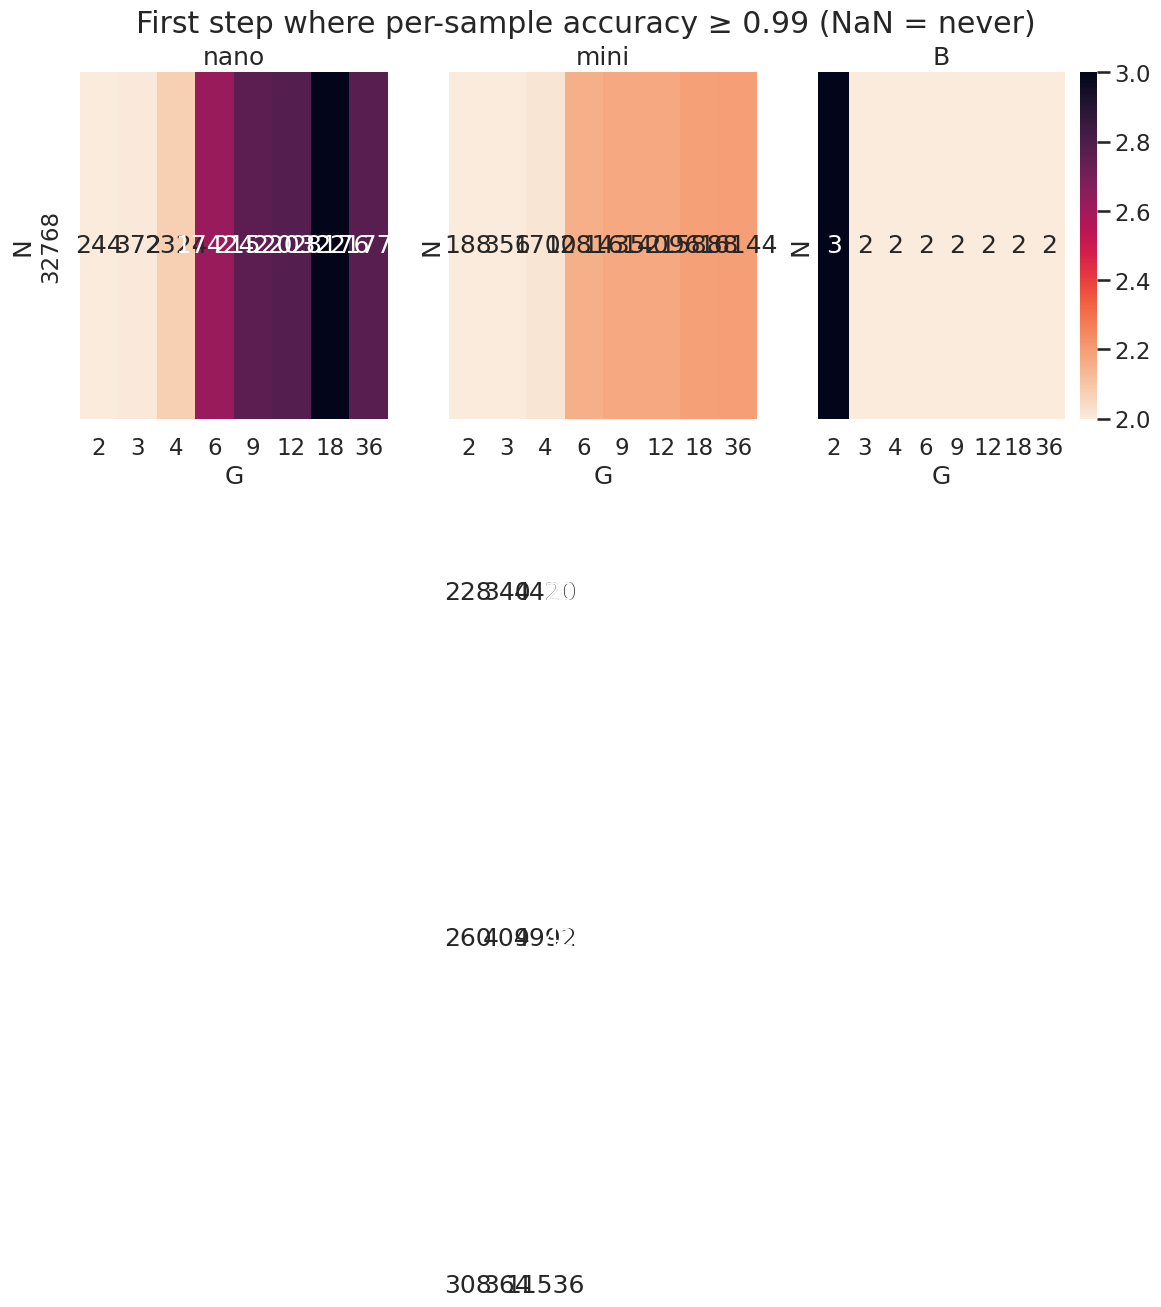

In [10]:
def heatmap_solve(thr, save=None):
    sizes = [s for s in ["nano","mini","B"] if s in solve_df["size"].unique()]
    fig, axes = plt.subplots(1, len(sizes), figsize=(4.5*len(sizes), 4.5), sharey=True)
    if len(sizes) == 1: axes = [axes]
    col = f"step_to_{thr}"
    for ax, size in zip(axes, sizes):
        sub = solve_df[solve_df["size"] == size]
        mat = sub.pivot(index="N", columns="G", values=col)
        sns.heatmap(mat, annot=True, fmt=".0f", cmap="rocket_r",
                    norm=None, ax=ax, cbar=(ax is axes[-1]))
        ax.set_title(f"{size}"); ax.set_xlabel("G"); ax.set_ylabel("N")
    fig.suptitle(f"First step where per-sample accuracy ≥ {thr} (NaN = never)", y=1.02)
    fig.tight_layout()
    if save:
        out = join(FIG_DIR, save)
        fig.savefig(out, dpi=130, bbox_inches="tight")
        print("saved:", out)
    plt.show()

heatmap_solve(0.5,  save="GPT_solve_step_0.5.png")
heatmap_solve(0.9,  save="GPT_solve_step_0.9.png")
heatmap_solve(0.99, save="GPT_solve_step_0.99.png")

## Memorization vs validity (final step)

If a run is "valid but memorizing" we expect `Sample_Mem_Ratio ≈ 1` together with `Sample_Accuracy ≈ 1`.
If a run is "generalizing" we expect high accuracy with low mem ratio.

saved: /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_mem_vs_acc_scatter.png


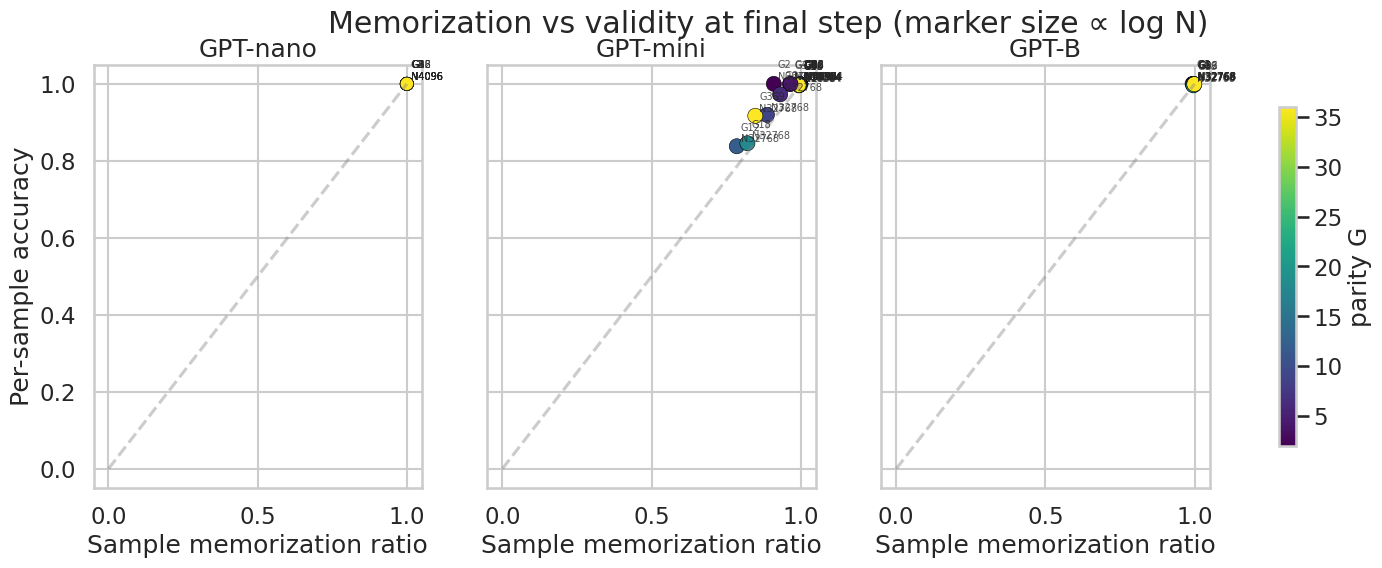

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharex=True, sharey=True)
sizes_present = [s for s in ["nano","mini","B"] if s in final_pivot["size"].unique()]
for ax, size in zip(axes, sizes_present):
    sub = final_pivot[final_pivot["size"] == size]
    sc = ax.scatter(sub["Eval/Sample_Mem_Ratio"], sub["Eval/Sample_Accuracy"],
                    c=sub["G"], cmap="viridis",
                    s=80 + 12*np.log2(sub["N"]/4096 + 1),
                    edgecolor="black", linewidth=0.4)
    for _, r in sub.iterrows():
        ax.annotate(f"G{r['G']}\nN{r['N']}",
                    (r["Eval/Sample_Mem_Ratio"], r["Eval/Sample_Accuracy"]),
                    fontsize=7, alpha=0.8, xytext=(3, 3), textcoords="offset points")
    ax.plot([0,1],[0,1], "--", c="gray", alpha=0.4)
    ax.set_xlabel("Sample memorization ratio")
    ax.set_title(f"GPT-{size}")
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
axes[0].set_ylabel("Per-sample accuracy")
cb = fig.colorbar(sc, ax=axes, shrink=0.8, label="parity G")
fig.suptitle("Memorization vs validity at final step (marker size ∝ log N)")
out = join(FIG_DIR, "GPT_mem_vs_acc_scatter.png")
fig.savefig(out, dpi=130, bbox_inches="tight")
print("saved:", out)
plt.show()